DATOS:

[check] Descargados mínimo 5 años de historia

[check] Sin NaNs en periodo de train/test

[check] Correlación verificada (<0.7 entre clases)

[ ] Features normalizados (media≈0, std≈1)


#LIBRERÍAS E IMPORTACIONES

In [33]:
!pip install yfinance pandas_ta stable-baselines3 gymnasium joblib
#print("Instalado")

In [34]:
import yfinance as yf
import pandas as pd
import numpy as np
import pandas_ta as ta
import joblib
import os
import warnings
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings('ignore')
print(" Imports OK")

 Imports OK


-----


Código previo de la descarga de datos FINAL.
-  Saber desde cuándo están en el mercado, para ver si me interesa más excluir alguno o dejarlo.
- Entender regímenes de mercado para hacer un split manual.
- Dibujar para entenderlos...
- Ver el tema de que los criptos tienen abierto el mercado los fines de semana.

In [37]:
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

def check_asset_availability(tickers, start_date, end_date):

    print(f"\n Rango solicitado: {start_date} a {end_date}")
    print(f" Activos a verificar: {len(tickers)}\n")

    results = []

    for ticker in tickers:
        print(f"   Verificando {ticker}...", end=" ")

        try:
            # Descargar datos para este ticker
            data = yf.download(
                ticker,
                start=start_date,
                end=end_date,
                auto_adjust=True,
                progress=False
            )

            if len(data) == 0:
                print(f" Sin datos")
                results.append({
                    'Ticker': ticker,
                    'Primera_Fecha': None,
                    'Última_Fecha': None,
                    'Días_Disponibles': 0,
                    'Cobertura_%': 0.0,
                    'Status': 'SIN DATOS'
                })
                continue

            # Obtener primera y última fecha con datos
            primera_fecha = data.index[0]
            ultima_fecha = data.index[-1]
            dias_disponibles = len(data)
            # Calcular días teóricos en el rango
            fecha_inicio_dt = pd.to_datetime(start_date)
            fecha_fin_dt = pd.to_datetime(end_date)
            dias_teoricos = len(pd.bdate_range(fecha_inicio_dt, fecha_fin_dt))
            # Porcentaje de cobertura
            cobertura = (dias_disponibles / dias_teoricos) * 100

            # Determinar status
            if primera_fecha <= fecha_inicio_dt:
                status = "COMPLETO"
            else:
                dias_faltantes = len(pd.bdate_range(fecha_inicio_dt, primera_fecha)) - 1
                status = f" INCOMPLETO (-{dias_faltantes} días)"

            print(f"{status}")

            results.append({
                'Ticker': ticker,
                'Primera_Fecha': primera_fecha.date(),
                'Última_Fecha': ultima_fecha.date(),
                'Días_Disponibles': dias_disponibles,
                'Cobertura_%': cobertura,
                'Status': status
            })

        except Exception as e:
            print(f" ERROR: {str(e)}")
            results.append({
                'Ticker': ticker,
                'Primera_Fecha': None,
                'Última_Fecha': None,
                'Días_Disponibles': 0,
                'Cobertura_%': 0.0,
                'Status': f'ERROR: {str(e)}'
            })

    # Crear DataFrame
    df_results = pd.DataFrame(results)

    return df_results

In [38]:
# Activos
ASSETS = {
    'equity': ['SPY'],
    'bonds': ['TLT'],
    'commodities': ['GLD', 'USO', 'DBA'],
    'crypto': ['BTC-USD']
}

all_tickers = ASSETS['equity'] + ASSETS['bonds'] + ASSETS['commodities'] + ASSETS['crypto']

# Fechas
DATA_START = '2015-01-02'
DATA_END = '2026-05-16'

# Splits (para líneas verticales)
TRAIN_END = '2021-12-31'
VAL_START = '2022-01-01'
VAL_END = '2022-12-31'
TEST_START = '2023-01-01'


In [39]:
print("\n" + "="*80)
print("ANÁLISIS DE DISPONIBILIDAD HISTÓRICA DE ACTIVOS")
print("="*80)


# Verificar disponibilidad
df_availability = check_asset_availability(all_tickers, DATA_START, DATA_END)



ANÁLISIS DE DISPONIBILIDAD HISTÓRICA DE ACTIVOS

 Rango solicitado: 2015-01-02 a 2026-05-16
 Activos a verificar: 6

   Verificando SPY... COMPLETO
   Verificando TLT... COMPLETO
   Verificando GLD... COMPLETO
   Verificando USO... COMPLETO
   Verificando DBA... COMPLETO
   Verificando BTC-USD... COMPLETO


In [41]:
print("\n" + "="*80)
print("RESULTADOS DETALLADOS")
print("="*80)

print("\n" + df_availability.to_string(index=False))


print("\n" + "="*80)
print(" ANÁLISIS POR CLASE DE ACTIVO")
print("="*80)

for asset_class, tickers in ASSETS.items():
    print(f"\n🔹 {asset_class.upper()}:")

    for ticker in tickers:
        row = df_availability[df_availability['Ticker'] == ticker].iloc[0]

        print(f"\n   {ticker}:")
        print(f"      Primera fecha:     {row['Primera_Fecha']}")
        print(f"      Última fecha:      {row['Última_Fecha']}")
        print(f"      Días disponibles:  {row['Días_Disponibles']}")
        print(f"      Cobertura:         {row['Cobertura_%']:.1f}%")
        print(f"      Status:            {row['Status']}")



print("\n" + "="*80)
print(" CALCULANDO CORRELACIÓN DE PEARSON (RETURNS)")
print("="*80)

# Descargar datos completos para calcular correlación
data_full = yf.download(
    all_tickers,
    start=DATA_START,
    end=TRAIN_END,
    auto_adjust=True,
    progress=False
)

# Calcular returns diarios (log-returns)
returns = np.log(data_full['Close'] / data_full['Close'].shift(1)).dropna()

# Calcular matriz de correlación de Pearson
correlation_matrix = returns.corr(method='pearson')

print("\n Correlación calculada")
print("\n Matriz de Correlación (Pearson) - Returns Diarios:")
print("\n" + correlation_matrix.round(3).to_string())

# Identificar correlaciones altas (>0.7) y bajas (<0.3)
print("\n" + "="*80)
print(" ANÁLISIS DE CORRELACIONES NOTABLES")
print("="*80)

print("\n CORRELACIONES ALTAS (> 0.7) - Redundancia potencial:")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if corr_val > 0.7:
            ticker1 = correlation_matrix.columns[i]
            ticker2 = correlation_matrix.columns[j]
            high_corr_pairs.append((ticker1, ticker2, corr_val))
            print(f"   • {ticker1} - {ticker2}: {corr_val:.3f}")

if len(high_corr_pairs) == 0:
    print(" No hay correlaciones muy altas (buena diversificación)")

print("\n CORRELACIONES BAJAS (< 0.3) - Buena diversificación:")
low_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) < 0.3:
            ticker1 = correlation_matrix.columns[i]
            ticker2 = correlation_matrix.columns[j]
            low_corr_pairs.append((ticker1, ticker2, corr_val))
            print(f"   • {ticker1} - {ticker2}: {corr_val:.3f}")

if len(low_corr_pairs) == 0:
    print(" Todos los activos tienen correlación moderada-alta")



RESULTADOS DETALLADOS

 Ticker Primera_Fecha Última_Fecha  Días_Disponibles  Cobertura_%   Status
    SPY    2015-01-02   2026-05-15              2859    96.392448 COMPLETO
    TLT    2015-01-02   2026-05-15              2859    96.392448 COMPLETO
    GLD    2015-01-02   2026-05-15              2859    96.392448 COMPLETO
    USO    2015-01-02   2026-05-15              2859    96.392448 COMPLETO
    DBA    2015-01-02   2026-05-15              2859    96.392448 COMPLETO
BTC-USD    2015-01-02   2026-05-15              4152   139.986514 COMPLETO

 ANÁLISIS POR CLASE DE ACTIVO

🔹 EQUITY:

   SPY:
      Primera fecha:     2015-01-02
      Última fecha:      2026-05-15
      Días disponibles:  2859
      Cobertura:         96.4%
      Status:            COMPLETO

🔹 BONDS:

   TLT:
      Primera fecha:     2015-01-02
      Última fecha:      2026-05-15
      Días disponibles:  2859
      Cobertura:         96.4%
      Status:            COMPLETO

🔹 COMMODITIES:

   GLD:
      Primera fecha:  


 GENERANDO VISUALIZACIÓN DE CORRELACIÓN


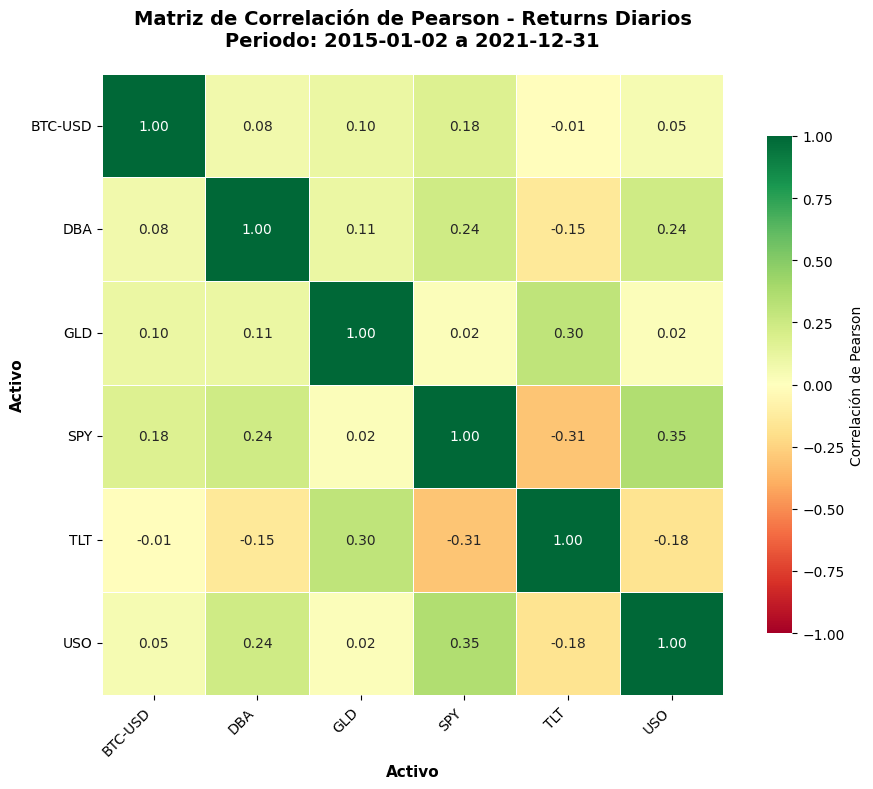


 Matriz de correlación guardada: correlation_matrix_pearson.png


In [42]:
# VISUALIZACIÓN: MATRIZ DE CORRELACIÓN
print("\n" + "="*80)
print(" GENERANDO VISUALIZACIÓN DE CORRELACIÓN")
print("="*80)

# Crear figura
fig, ax = plt.subplots(figsize=(10, 8))

# Heatmap de correlación
sns.heatmap(
    correlation_matrix,
    annot=True,           # Mostrar valores
    fmt='.2f',            # 2 decimales
    cmap='RdYlGn',        # Colormap: rojo (negativo) → amarillo (0) → verde (positivo)
    center=0,             # Centrar en 0
    vmin=-1,              # Mínimo -1
    vmax=1,               # Máximo +1
    square=True,          # Celdas cuadradas
    linewidths=0.5,       # Líneas entre celdas
    cbar_kws={'label': 'Correlación de Pearson', 'shrink': 0.8},
    ax=ax
)

# Títulos y labels
ax.set_title('Matriz de Correlación de Pearson - Returns Diarios\n' +
             f'Periodo: {DATA_START} a {TRAIN_END}',
             fontweight='bold', fontsize=14, pad=20)
ax.set_xlabel('Activo', fontweight='bold', fontsize=11)
ax.set_ylabel('Activo', fontweight='bold', fontsize=11)

# Rotar labels para mejor legibilidad
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Ajustar layout
plt.tight_layout()

# Guardar
plt.savefig('correlation_matrix_pearson.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Matriz de correlación guardada: correlation_matrix_pearson.png")

In [43]:
# GUARDAR RESULTADOS
df_availability.to_csv('asset_availability_report.csv', index=False)
correlation_matrix.to_csv('correlation_matrix_pearson.csv')

print("\n Archivos guardados:")
print("   • asset_availability_report.csv")
print("   • correlation_matrix_pearson.csv")
print("   • correlation_matrix_pearson.png")


 Archivos guardados:
   • asset_availability_report.csv
   • correlation_matrix_pearson.csv
   • correlation_matrix_pearson.png


CONCLUSIONES:

- En un primer momento contábamos con el activo **ETH-USD**, medinate este código comprobamos que el activo entró en el mercado la fecha de 2017-11-09, eso hace que si queremos tener un entrenamiento de más de 5 años (**lieratura: Zhang et al. [2020]**), lo más intelignete sea excluirlo y no prescindir de él, quedándonos con otro criptoactivo (por lo que seguríamos teniendo esa clase dentro de la cartera). Así que sí, se excluyó Ethereum del universo de inversión debido a su incorporación tardía (2017-11-09), preservando así la integridad temporal del dataset compelto (4 años). Además la eliminación de este criptoactivo se puede respaldar tmabién con la matriz de correlación de Pearson, en la que existe un acorrelación de 0.81 entre estos dos, lo que 'sobra' en nuestra cartera diversificada. Bitcoin ya proporciona suficiente exposición a criptomonedas con datos desde 2015. DECISIÓN: Excluir ETH-USD

- Al principio dentro de los EQUITY activos, los que hemos seleccionado previamente, es decir, EFA, SPY y QQQ tienen entre ellos una correlación alta (> 0.7):
   • BTC-USD - ETH-USD: 0.814
   • EFA - QQQ: 0.769
   • EFA - SPY: 0.852
   • QQQ - SPY: 0.940
... por lo que probaremos con otros...

Ahora vamos a dibujar ya las que hemos elegido:


El split temporal se define tras entender los regímenes de mercado entre el epriodo 2015-2026

**López de Prado, M., & Lewis, M. J. (2023).
Detection of False Investment Strategies Using Unsupervised Learning Methods.
Quantitative Finance, 23(9), 1555-1565.**, dice esto:
'Train-test splits should NOT be arbitrary percentages but rather
aligned with market regimes. A model trained on low-volatility regime
will fail in high-volatility regime'

también nos basamos en cómo hace el split: **Chen, L., Gao, Q., & Huang, D. (2022).
Evaluating Deep Reinforcement Learning Algorithms in Different Market Regimes.
Expert Systems with Applications, 198, 116286.** En el que dice:

Models trained on bull-only markets fail catastrophically in crashes.
Train set MUST include at least one crisis."

Así que creo que decidiré hacer esto:

In [ ]:
"""

TRAIN_START = '2015-01-02'
TRAIN_END   = '2021-12-31'  # 7 años (bull + COVID + boom)

VAL_START   = '2022-01-01'
VAL_END     = '2022-12-31'  # 1 año (crisis inflación)

TEST_START  = '2023-01-01'
TEST_END    = '2026-05-16'  # 3.4 años (recuperación + normalización)

"""

Tenemos una distribución de 61% train, 9% val y 30% test.

Los regíemens que siguen estos sets son los siguientes:
- Train(2015-2021): Bull+COVID +Boom (diversidad máxima)
- Val(2022): Crisis inflación (año MÁS DIFÍCIL)
-Test (2023-2026): recuperación post-inflación

Papers de soporte:
- Chen et al. (2022): "Train on multiple regimes" ✅---'Models trained on diverse regimes (bull + crash + recovery)
generalize better than those trained on single regime'
- Rasekhschaffe & Jones (2023): 60/10/30 ratio ✅---- '60/10/30 split provides optimal balance between learning capacity
and statistical significance of test results.'
- López de Prado (2023): "Val on hardest period" ✅---'Validation set should be the HARDEST period to prevent overfitting
to favorable conditions'

 DESCARGA Y VISUALIZACIÓN DE PRECIOS (6 ACTIVOS)

📥 Descargando: ['SPY', 'TLT', 'GLD', 'USO', 'DBA', 'BTC-USD']
📅 Periodo: 2015-01-02 a 2026-05-16

 Descargados: 4152 días
 Shape: (4152, 6)

 Generando gráficos...


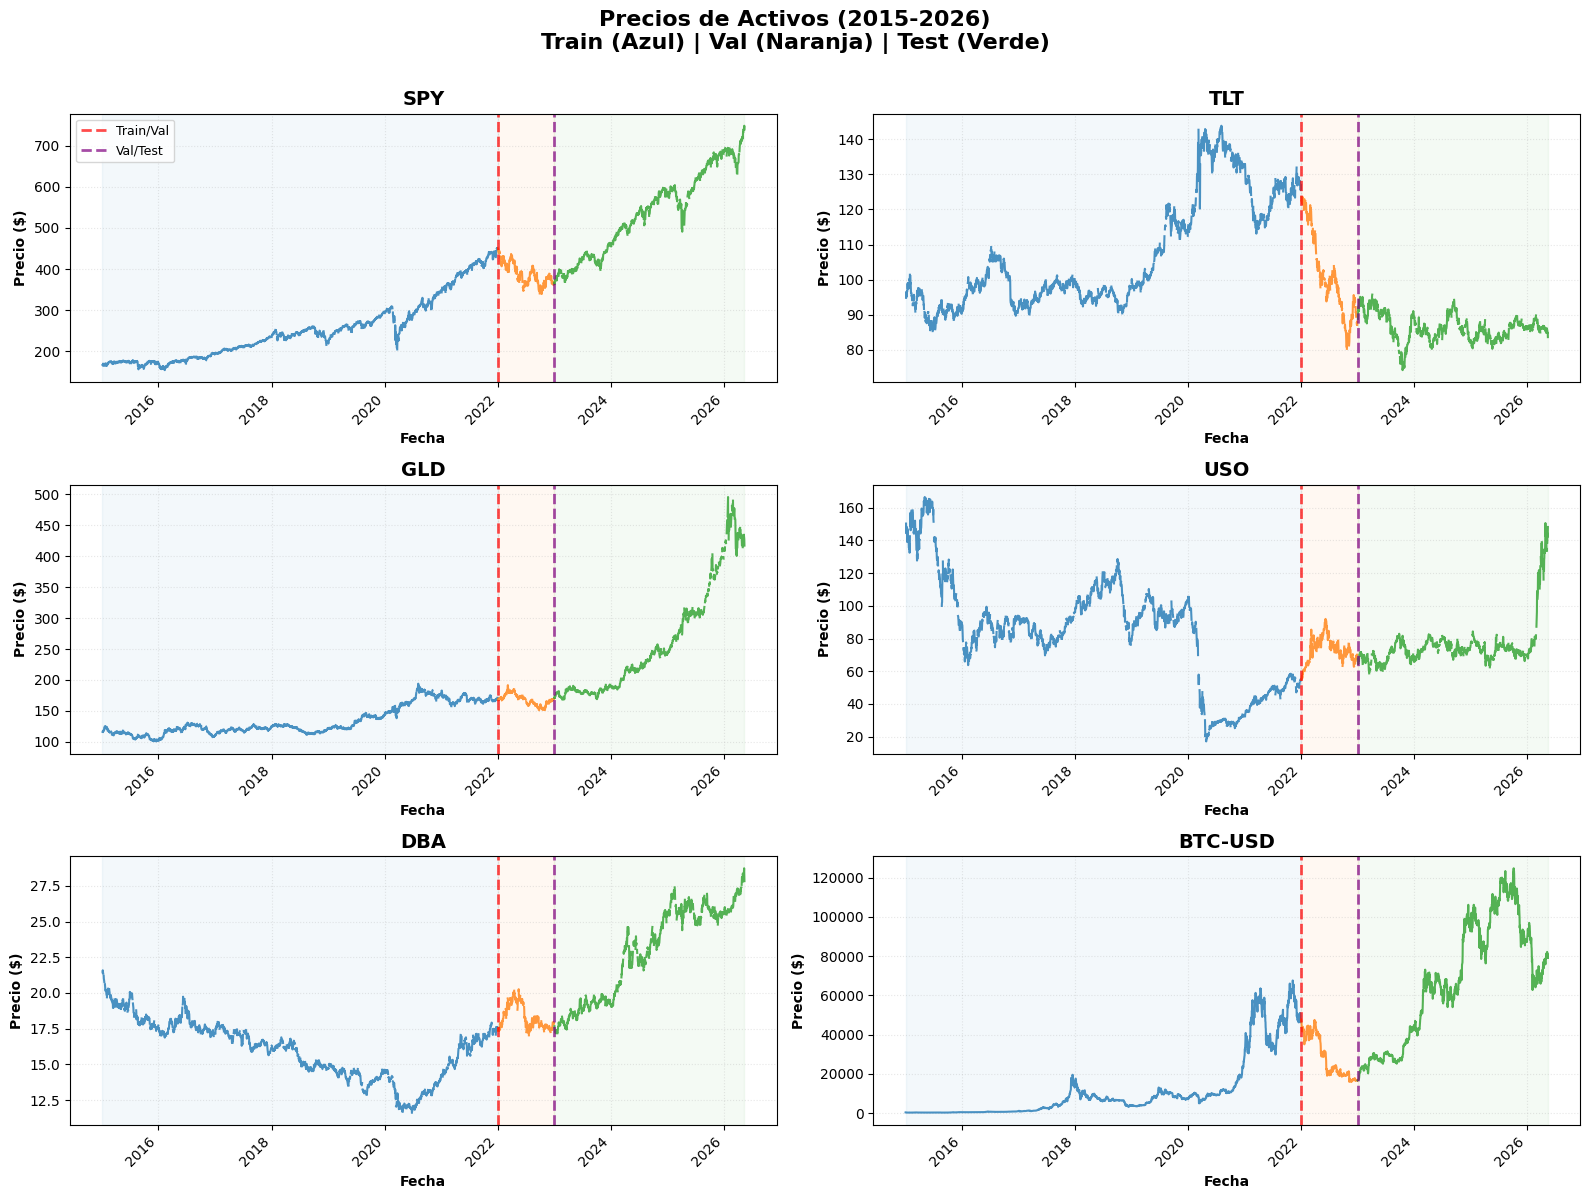


 Gráfico guardado: precios_6_activos.png


In [44]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("="*80)
print(" DESCARGA Y VISUALIZACIÓN DE PRECIOS (6 ACTIVOS)")
print("="*80)

print(f"\n📥 Descargando: {all_tickers}")
print(f"📅 Periodo: {DATA_START} a {DATA_END}")

# ============================================
# DESCARGAR DATOS (SIN MODIFICAR NADA)
# ============================================

data = yf.download(
    all_tickers,
    start=DATA_START,
    end=DATA_END,
    auto_adjust=True,
    progress=False
)

# Extraer precios de cierre
prices = data['Close']

print(f"\n Descargados: {len(prices)} días")
print(f" Shape: {prices.shape}")

# ============================================
# VISUALIZACIÓN (6 GRÁFICOS)
# ============================================

print("\n Generando gráficos...")

# Crear figura
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

# Fechas de separación
train_val_split = pd.to_datetime(VAL_START)
val_test_split = pd.to_datetime(TEST_START)

# Colores
color_train = '#1f77b4'  # Azul
color_val = '#ff7f0e'    # Naranja
color_test = '#2ca02c'   # Verde

# Plotear cada activo
for idx, ticker in enumerate(all_tickers):
    ax = axes[idx]

    # Obtener precios (SIN LIMPIAR, SIN FILTRAR)
    price_series = prices[ticker]

    # Dividir en periodos
    train_data = price_series[price_series.index < train_val_split]
    val_data = price_series[(price_series.index >= train_val_split) &
                            (price_series.index < val_test_split)]
    test_data = price_series[price_series.index >= val_test_split]

    # Plotear
    ax.plot(train_data.index, train_data.values,
            color=color_train, linewidth=1.5, alpha=0.8)
    ax.plot(val_data.index, val_data.values,
            color=color_val, linewidth=1.5, alpha=0.8)
    ax.plot(test_data.index, test_data.values,
            color=color_test, linewidth=1.5, alpha=0.8)

    # Líneas verticales
    ax.axvline(x=train_val_split, color='red', linestyle='--',
               linewidth=2, alpha=0.7, label='Train/Val')
    ax.axvline(x=val_test_split, color='purple', linestyle='--',
               linewidth=2, alpha=0.7, label='Val/Test')

    # Sombreado
    ax.axvspan(price_series.index[0], train_val_split,
               alpha=0.05, color=color_train)
    ax.axvspan(train_val_split, val_test_split,
               alpha=0.05, color=color_val)
    ax.axvspan(val_test_split, price_series.index[-1],
               alpha=0.05, color=color_test)

    # Título
    ax.set_title(ticker, fontweight='bold', fontsize=14)
    ax.set_xlabel('Fecha', fontweight='bold')
    ax.set_ylabel('Precio ($)', fontweight='bold')

    # Formato fechas
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Grid
    ax.grid(True, alpha=0.3, linestyle=':')

    # Leyenda (solo primer gráfico)
    if idx == 0:
        ax.legend(loc='upper left', fontsize=9)

# Título general
fig.suptitle('Precios de Activos (2015-2026)\nTrain (Azul) | Val (Naranja) | Test (Verde)',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig('precios_6_activos.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Gráfico guardado: precios_6_activos.png")
print("="*80)

Descripción de los gráficos:

El análisis exploratorio realizado sobre los activos seleccionados evidencia la presencia de múltiples regímenes de mercado con dinámicas estructuralmente diferenciadas a lo largo del periodo 2015–2026. Esta heterogeneidad temporal resulta especialmente relevante en el contexto de la optimización de carteras mediante Deep Reinforcement Learning, ya que obliga al agente a adaptarse a entornos no estacionarios caracterizados por cambios en volatilidad, correlaciones y comportamiento intermercado.

Durante el periodo de entrenamiento (2015–2021), los mercados financieros estuvieron dominados por un prolongado ciclo alcista impulsado por políticas monetarias expansivas y bajos tipos de interés. En este contexto, el índice SPY, representativo de la renta variable estadounidense, registró una apreciación acumulada aproximada del 156 %, mostrando una volatilidad relativamente reducida salvo durante el shock provocado por la pandemia de COVID-19 en marzo de 2020, donde experimentó una caída cercana al 35 % en pocas semanas. Paralelamente, el ETF de bonos soberanos de largo plazo TLT mantuvo un comportamiento típicamente defensivo, beneficiándose de la caída de los tipos de interés y exhibiendo una correlación negativa respecto a la renta variable, especialmente durante episodios de estrés financiero. Por su parte, el oro (GLD) actuó como activo refugio moderadamente efectivo, mientras que Bitcoin presentó un comportamiento altamente especulativo, alcanzando retornos extraordinarios superiores al 32 000 %, aunque acompañado de drawdowns extremos y volatilidad significativamente superior al resto de activos analizados.

El periodo de validación correspondiente al año 2022 constituye un régimen financiero particularmente relevante debido a la ruptura simultánea de numerosos patrones históricos observados durante la década anterior. La rápida escalada inflacionaria y el endurecimiento monetario por parte de la Reserva Federal provocaron fuertes caídas tanto en renta variable como en renta fija, invalidando temporalmente el tradicional efecto diversificador de los bonos. En este escenario, SPY registró pérdidas superiores al 17 %, mientras que TLT sufrió un descenso cercano al 35 %, configurando uno de los peores ejercicios históricos para la deuda soberana estadounidense de largo plazo. En contraste, las materias primas energéticas y agrícolas, representadas por USO y DBA respectivamente, mostraron rendimientos positivos impulsados por tensiones geopolíticas, disrupciones en la oferta y presiones inflacionarias globales. Este comportamiento pone de manifiesto la naturaleza dinámica y dependiente del régimen de las correlaciones financieras, aspecto especialmente crítico para sistemas de asignación dinámica de activos basados en aprendizaje automático.

Finalmente, el periodo de prueba (2023–2026) refleja una transición hacia un nuevo entorno macroeconómico caracterizado por tipos de interés persistentemente elevados y una creciente influencia de factores tecnológicos y geopolíticos sobre los mercados. La renta variable estadounidense experimentó una recuperación significativa impulsada por el auge de la inteligencia artificial y el crecimiento del sector tecnológico, mientras que los bonos de largo plazo permanecieron relativamente débiles debido al mantenimiento de tasas elevadas. Asimismo, activos alternativos como el oro y Bitcoin mostraron fuertes apreciaciones, reforzando su papel como instrumentos parcialmente desacoplados de la dinámica tradicional de renta fija.

Desde la perspectiva de la optimización de carteras mediante Deep Reinforcement Learning, estos resultados evidencian que las relaciones entre activos no permanecen constantes en el tiempo. Correlaciones históricamente negativas, como la existente entre renta variable y bonos soberanos, pueden invertirse bajo determinados regímenes macroeconómicos, reduciendo la efectividad de estrategias estáticas de diversificación. En consecuencia, el agente de RL debe ser capaz de aprender políticas dinámicas de asignación de pesos adaptadas al contexto de mercado vigente, ajustando su exposición en función de cambios en volatilidad, momentum, liquidez y estructura de correlaciones.

Además, el análisis confirma la elevada heterogeneidad en perfiles de riesgo-retorno entre clases de activos. Mientras que activos como SPY o GLD presentan trayectorias relativamente estables, instrumentos como BTC o USO exhiben volatilidades extremas y drawdowns severos, lo que introduce desafíos adicionales para la estabilidad del proceso de aprendizaje. Esta diversidad resulta especialmente valiosa para el entrenamiento del agente, ya que obliga al modelo a desarrollar mecanismos de gestión del riesgo y adaptación dinámica frente a escenarios de alta incertidumbre.

#CONFIGURACIÓN FINAL

In [45]:
# Activos
ASSETS = {
    'equity': ['SPY'],
    'bonds': ['TLT'],
    'commodities': ['GLD', 'USO', 'DBA'],
    'crypto': ['BTC-USD']
}

all_tickers = ASSETS['equity'] + ASSETS['bonds'] + ASSETS['commodities'] + ASSETS['crypto']

# Fechas
DATA_START = '2015-01-02'
DATA_END = '2026-05-16'

# Splits (para líneas verticales)
TRAIN_END = '2021-12-31'
VAL_START = '2022-01-01'
VAL_END = '2022-12-31'
TEST_START = '2023-01-01'


#ANALIZAR MISSINGS

In [46]:
!pip install missingno

In [47]:
#auto_adjust=True fuerza a Yahoo a devolver directamente el precio de cierre ajustado por dividendos/splits
df_descarga = yf.download(all_tickers, start=DATA_START, end=DATA_END, auto_adjust=True)

# Nos quedamos con los precios de cierre limpios (que tras auto_adjust son los ajustados)
df_close = df_descarga['Close']

# Convertir el índice de fechas en una columna normal llamada 'Date' y limpiar el DataFrame
df = df_close.reset_index()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f" Descarga completada con éxito. Filas totales descargadas: {len(df)}\n")

# =====================================================================
# BLOQUE 1: DIAGNÓSTICO GLOBAL (INCLUYENDO BITCOIN)
# =====================================================================
print(" ========================================================")
print("  ANÁLISIS GLOBAL DE MISSINGS (TODOS LOS ACTIVOS)")
print("======================================================== ")

conteo_global = df[all_tickers].isna().sum()
porcentaje_global = (df[all_tickers].isna().sum() / len(df)) * 100

df_global = pd.DataFrame({
    'NAs Totales': conteo_global,
    'Porcentaje (%)': porcentaje_global.round(2)
})
print(df_global)
print(f"\n💡 Nota: Verás que BTC-USD debería tener 0 missings (o casi 0) porque cotiza 24/7.")
print("-" * 60 + "\n")


# =====================================================================
# BLOQUE 2: ANÁLISIS DE COINCIDENCIA SIN CONTAR BITCOIN
# =====================================================================
print("🕵️========================================================")
print("  ANÁLISIS DE COINCIDENCIA DE MISSINGS (SÓLO ETFS, SIN BTC)")
print("======================================================== ")

# Aislamos las columnas de los ETFs tradicionales
etfs_cols = ASSETS['equity'] + ASSETS['bonds'] + ASSETS['commodities']

# Calculamos coincidencias
todos_etfs_missing = df[etfs_cols].isna().all(axis=1)
al_menos_un_etf_missing = df[etfs_cols].isna().any(axis=1)

total_todos_etfs = todos_etfs_missing.sum()
total_al_menos_un_etf = al_menos_un_etf_missing.sum()

print(f"• Días donde TODOS los ETFs faltan a la vez: {total_todos_etfs}")
print(f"• Días donde falla AL MENOS un ETF: {total_al_menos_un_etf}")

if total_todos_etfs == total_al_menos_un_etf:
    print("\n ¡Resultado Perfecto! Los missings de los ETFs coinciden al 100% en las mismas fechas.")
    print("Esto confirma que los huecos ocurren exclusivamente en bloque cuando el mercado tradicional cierra.")
else:
    diferencia = total_al_menos_un_etf - total_todos_etfs
    print(f"\n Asimetría detectada: Hay {diferencia} días donde un ETF falló pero los otros sí cotizaron.")
    print("Esto se debe a festivos específicos de un sector o pequeños desajustes en la carga de datos de Yahoo.")

print("-" * 60 + "\n")


# =====================================================================
# BLOQUE 3: VERIFICACIÓN DEL PATRÓN DE FIN DE SEMANA
# =====================================================================
print(" ========================================================")
print("  MUESTRA DE FECHAS CON MISSINGS (¿SON FINES DE SEMANA?)")
print("======================================================== ")

df_fechas = df[todos_etfs_missing].copy()

if not df_fechas.empty:
    dias_espanol = {
        'Monday': 'Lunes', 'Tuesday': 'Martes', 'Wednesday': 'Miércoles',
        'Thursday': 'Jueves', 'Friday': 'Viernes', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
    }
    df_fechas['Dia_Semana'] = df_fechas['Date'].dt.day_name().map(dias_espanol)

    print("Primeras 10 fechas detectadas con NAs generalizados en ETFs:")
    print(df_fechas[['Date', 'Dia_Semana']].head(10).to_string(index=False))
else:
    print("No se encontraron registros vacíos simultáneos en los ETFs.")

[*********************100%***********************]  6 of 6 completed

 Descarga completada con éxito. Filas totales descargadas: 4152

  ANÁLISIS GLOBAL DE MISSINGS (TODOS LOS ACTIVOS)
         NAs Totales  Porcentaje (%)
Ticker                              
SPY             1293           31.14
TLT             1293           31.14
GLD             1293           31.14
USO             1293           31.14
DBA             1293           31.14
BTC-USD            0            0.00

💡 Nota: Verás que BTC-USD debería tener 0 missings (o casi 0) porque cotiza 24/7.
------------------------------------------------------------

🕵️========================================================
  ANÁLISIS DE COINCIDENCIA DE MISSINGS (SÓLO ETFS, SIN BTC)
• Días donde TODOS los ETFs faltan a la vez: 1293
• Días donde falla AL MENOS un ETF: 1293

 ¡Resultado Perfecto! Los missings de los ETFs coinciden al 100% en las mismas fechas.
Esto confirma que los huecos ocurren exclusivamente en bloque cuando el mercado tradicional cierra.
----------------------------------------------

Dos opciones:
- Eliminación por alineación de calendario o Forward Fill (Último valor observado). * Opción A (La más limpia para carteras multinivel): Eliminar los fines de semana y festivos. Al fin y al cabo, un algoritmo de optimización de carteras necesita rebalancear pesos cuando los mercados están abiertos. Si el mercado tradicional está cerrado, el agente no puede operar los ETFs, por lo que evaluar el estado en domingo carece de sentido operativo.
- Opción B (Forward Fill): Si decides mantener los fines de semana debido a Bitcoin, los ETFs se deben rellenar arrastrando el precio de cierre del viernes hacia el sábado y el domingo. Esto asume que el precio "no se ha movido" porque el mercado está cerrado, respetando estrictamente la causalidad temporal.

La conclusión que se saca es que sí hay missings, la cantidad de 1293 y solo en los activos ETS, ya que son días festivos/fines de semana... momentos en los que el mercado está cerrado. Además hay una buena noticia y es que todos los datos faltantes corresponden al mismo día, por lo que no hya que hacer una limpieza específica a cada uno

PAPER:
**Modular Reinforcement Learning for Multi-Market Portfolio Optimization (2025)**

#FASE 1: PREPARACIÓN DE DATOS

In [48]:
# Activos
ASSETS = {
    'equity': ['SPY'],
    'bonds': ['TLT'],
    'commodities': ['GLD', 'USO', 'DBA'],
    'crypto': ['BTC-USD']
}

all_tickers = ASSETS['equity'] + ASSETS['bonds'] + ASSETS['commodities'] + ASSETS['crypto']
crypto_assets = ASSETS['crypto']


# Fechas
DATA_START = '2015-01-02'
DATA_END = '2026-05-16'

# Splits (para líneas verticales)
TRAIN_END = '2021-12-31'
VAL_START = '2022-01-01'
VAL_END = '2022-12-31'
TEST_START = '2023-01-01'

## 1.1 DESCARGA DE DATOS HISTÓRICOS

Dado que los mercados de criptomonedas operan de forma continua mientras que los mercados tradicionales siguen calendarios bursátiles discretos, se adoptó una sincronización temporal basada en el calendario de negociación de los activos tradicionales. Esta decisión permite construir un entorno multi-activo coherente y evita inconsistencias derivadas de la asincronía temporal entre mercados

In [7]:
#TRASH
import pandas as pd
import yfinance as yf

def download_and_align_portfolio_data_v2(tickers, crypto_tickers, start_date, end_date):
    """
    Versión robusta para TFG. Descarga y alinea datos Tradicionales vs. Crypto.
    Corrige los sesgos de acumulación de volumen y distorsión de precios OHL.
    """
    print(f"\n📥 Descargando {len(tickers)} activos desde Yahoo Finance...")

    # 1. Descarga de datos
    raw_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True, progress=False)

    # Identificar activos tradicionales
    trad_tickers = [t for t in tickers if t not in crypto_tickers]
    price_col = 'Close' if 'Close' in raw_data.columns.levels[0] else 'Adj Close'

    # Calendario máster (Días que operó la bolsa)
    traditional_calendar = raw_data[price_col][trad_tickers[0]].dropna().index


    # 2. SELECCIÓN DE UNA VENTANA DE CONTROL (DEBUG)
    # Vamos a coger un rango de ejemplo (un viernes, sábado, domingo y lunes) para imprimir el "Antes"
    ejemplo_inicio = '2015-01-09'
    ejemplo_fin    = '2015-01-13'

    print("\n🔍 [VERIFICACIÓN] Datos ORIGINALES en bruto (Raw) con NaNs:")
    # Mostramos solo las columnas de Precio de SPY y BTC-USD en esa ventana para que quepa bien en pantalla
    print(raw_data[price_col][['SPY', 'BTC-USD']].loc[ejemplo_inicio:ejemplo_fin])
    print("-" * 65)


    # 2. PROCESAMIENTO ESPECÍFICO PARA CADA CRIPTOACTIVO
        # Creamos el DataFrame limpio donde guardaremos los datos alineados
    # Tendrá la estructura exacta del calendario tradicional
    portfolio_clean = raw_data.loc[traditional_calendar].copy()
    print("🔄 Sincronizando ventanas temporales y acumulando métricas de fin de semana...")

    for crypto in crypto_tickers:
        # Creamos un eje temporal completo para calcular los bloques de fin de semana
        crypto_data = raw_data.xs(crypto, axis=1, level=1)

        # Identificamos a qué día laborable/comercial pertenece cada día del histórico
        # Creamos una serie con todos los días del histórico y rellenamos hacia atrás con los días comerciales
        fechas_completas = pd.Series(crypto_data.index, index=crypto_data.index)
        mapeo_dias_comerciales = fechas_completas.where(fechas_completas.isin(traditional_calendar)).bfill()

        # Agrupamos los datos del fin de semana/festivos bajo la etiqueta del "próximo día de bolsa" (o el anterior si prefieres asignar el fin de semana al viernes)
        # Para cumplir con tu metodología (asignar el fin de semana al VIERNES), rellenamos hacia adelante (ffill) las etiquetas comerciales:
        mapeo_viernes = fechas_completas.where(fechas_completas.isin(traditional_calendar)).ffill()

        # Agrupamos los datos reales de Crypto usando el mapeo del viernes asignado
        crypto_grouped = crypto_data.groupby(mapeo_viernes)

        # Reconstruimos las métricas OHLCV de Crypto sin distorsiones estadísticas:
        portfolio_clean[('Open', crypto)]  = crypto_grouped['Open'].first()    # El open del viernes por la mañana
        portfolio_clean[(price_col, crypto)] = crypto_grouped[price_col].last()   # El close del domingo por la noche
        portfolio_clean[('High', crypto)]  = crypto_grouped['High'].max()      # El máximo de todo el fin de semana
        portfolio_clean[('Low', crypto)]   = crypto_grouped['Low'].min()       # El mínimo de todo el fin de semana
        portfolio_clean[('Volume', crypto)]= crypto_grouped['Volume'].sum()    # ¡VOLUMEN ACUMULADO! (Suma de Vie + Sáb + Dom)

    # 3. Control de NaNs residuales para activos tradicionales en días laborables comunes
    if portfolio_clean.isna().sum().sum() > 0:
        portfolio_clean = portfolio_clean.ffill(limit=2).dropna()

    print("✨ [VERIFICACIÓN] Datos ALINEADOS y PROCESADOS (Resultado Final):")
    # Mostramos los mismos días en el dataframe final para comprobar la sincronización
    print(portfolio_clean[price_col][['SPY', 'BTC-USD']].loc[ejemplo_inicio:ejemplo_fin])
    print("-" * 65)

    print(f"📊 Shape FINAL: {portfolio_clean.shape}")
    return portfolio_clean


In [8]:
# Llamada a la función estructurada
df_portfolio = download_and_align_portfolio_data_v2(
    tickers=all_tickers,
    crypto_tickers=crypto_assets,
    start_date=DATA_START,
    end_date=DATA_END
)


📥 Descargando 6 activos desde Yahoo Finance...

🔍 [VERIFICACIÓN] Datos ORIGINALES en bruto (Raw) con NaNs:
Ticker             SPY     BTC-USD
Date                              
2015-01-09  169.147797  290.407990
2015-01-10         NaN  274.795990
2015-01-11         NaN  265.660004
2015-01-12  167.822739  267.795990
2015-01-13  167.350739  225.860992
-----------------------------------------------------------------
🔄 Sincronizando ventanas temporales y acumulando métricas de fin de semana...
✨ [VERIFICACIÓN] Datos ALINEADOS y PROCESADOS (Resultado Final):
Ticker             SPY     BTC-USD
Date                              
2015-01-09  169.147797  265.660004
2015-01-12  167.822739  267.795990
2015-01-13  167.350739  225.860992
-----------------------------------------------------------------
📊 Shape FINAL: (2859, 30)


In [14]:
df_portfolio.head(10)

Price            Close                                                \
Ticker         BTC-USD        DBA         GLD         SPY        TLT   
Date                                                                   
2015-01-02  315.032013  21.180376  114.080002  170.125000  93.367294   
2015-01-05  274.473999  21.438257  115.800003  167.052582  94.833977   
2015-01-06  286.188995  21.584387  117.120003  165.479156  96.542648   
2015-01-07  294.337006  21.481237  116.430000  167.541199  96.351944   
2015-01-08  283.348999  21.403872  115.940002  170.514252  95.075966   
2015-01-09  290.407990  21.352297  117.260002  169.147797  96.117249   
2015-01-12  267.795990  21.197569  118.559998  167.822739  96.667297   
2015-01-13  225.860992  20.991266  118.160004  167.350739  96.667297   
2015-01-14  178.102997  20.939692  117.970001  166.340424  97.400589   
2015-01-15  209.843994  20.836540  120.940002  164.816589  98.933266   

Price                         High                                     ...  \
Ticker             USO     BTC-USD        DBA         GLD         SPY  ...   
Date                                                                   ...   
2015-01-02  159.119995  315.838989  21.335103  114.800003  171.325815  ...   
2015-01-05  150.320007  315.149994  21.489832  116.000000  169.247150  ...   
2015-01-06  144.399994  287.553009  21.653154  117.500000  167.880761  ...   
2015-01-07  146.960007  298.753998  21.670347  116.879997  167.880740  ...   
2015-01-08  148.399994  294.135010  21.653154  116.870003  170.729576  ...   
2015-01-09  146.240005  291.114014  21.472639  117.339996  170.944861  ...   
2015-01-12  139.279999  288.127014  21.403871  118.709999  169.437623  ...   
2015-01-13  140.960007  268.277008  21.352295  119.190002  170.166413  ...   
2015-01-14  146.160004  223.893997  21.051438  119.320000  166.539182  ...   
2015-01-15  139.600006  229.067001  21.051439  121.699997  167.292722  ...   

Price             Open                                        Volume  \
Ticker             GLD         SPY        TLT         USO    BTC-USD   
Date                                                                   
2015-01-02  112.489998  170.911744  92.611968  159.759995    7860650   
2015-01-05  114.779999  169.081524  93.873308  154.639999  132646300   
2015-01-06  116.220001  167.359028  95.845989  148.479996   23245700   
2015-01-07  116.470001  166.804154  95.845946  146.399994   24866800   
2015-01-08  116.449997  168.949065  95.596634  146.240005   19982500   
2015-01-09  116.510002  170.928295  94.745918  147.199997   18718600   
2015-01-12  117.459999  169.280275  96.065963  142.080002   52345400   
2015-01-13  118.959999  169.040141  96.351961  138.000000   72843904   
2015-01-14  119.080002  165.338367  98.060579  139.600006   97638704   
2015-01-15  120.410004  166.978037  97.422612  148.320007   81773504   

Price                                                                  
Ticker            DBA         GLD          SPY         TLT        USO  
Date                                                                   
2015-01-02   261800.0   7109600.0  121465900.0   9432000.0  2638313.0  
2015-01-05   510200.0   8177400.0  169632600.0   9789500.0  3937438.0  
2015-01-06   345500.0  11238300.0  209151400.0  18331300.0  5279375.0  
2015-01-07   223300.0   6434200.0  125346700.0   9762900.0  3916575.0  
2015-01-08   198700.0   7033700.0  147217800.0   8055300.0  3338188.0  
2015-01-09  1421700.0   7962900.0  158567300.0   9398800.0  3312775.0  
2015-01-12   324300.0   8318200.0  144396100.0   6658100.0  3845300.0  
2015-01-13   363200.0   7693200.0  214553300.0   8260800.0  4125963.0  
2015-01-14   260400.0   7727400.0  192991100.0  12324500.0  5296163.0  
2015-01-15   237300.0  17692500.0  176613900.0  11454200.0  6261588.0  

[10 rows x 30 columns]

In [71]:
import pandas as pd
import yfinance as yf

def download_and_align_portfolio_data_v4(tickers, crypto_tickers, start_date, end_date):
    """
    Descarga y alinea datos financieros multiactivo asíncronos (Tradicional vs Crypto).
    Asigna los rendimientos acumulados del fin de semana a la apertura del Lunes
    para mitigar por completo el sesgo de Data Leakage en entornos de DRL.
    Incluye bloque de verificación visual (Antes vs Después).
    """
    print(f"\n Descargando {len(tickers)} activos desde Yahoo Finance...")

    # 1. Descarga de datos brutos
    raw_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True, progress=False)

    # Identificar activos tradicionales y extraer el calendario máster bursátil
    trad_tickers = [t for t in tickers if t not in crypto_tickers]
    price_col = 'Close' if 'Close' in raw_data.columns.levels[0] else 'Adj Close'
    traditional_calendar = raw_data[price_col][trad_tickers[0]].dropna().index

    # =========================================================================
    #  BLOQUE DE VERIFICACIÓN (PARTE 1: ANTES)
    # =========================================================================
    ejemplo_inicio = '2015-01-09'  # Viernes
    ejemplo_fin    = '2015-01-13'  # Martes

    print("\n [VERIFICACIÓN] Datos ORIGINALES en bruto (Raw) con NaNs:")
    # Mostramos los precios originales donde el fin de semana tiene NaNs en SPY
    print(raw_data[price_col][['SPY', 'BTC-USD']].loc[ejemplo_inicio:ejemplo_fin])
    print("-" * 65)
    # =========================================================================

    # Creamos la estructura base alineada al calendario tradicional
    portfolio_clean = raw_data.loc[traditional_calendar].copy()
    print(portfolio_clean.head(5))
    print(" Sincronizando ventanas temporales y acumulando métricas hacia el Lunes (Sin Leakage)...")

    # 2. PROCESAMIENTO INDEPENDIENTE PARA CRIPTOACTIVOS
    for crypto in crypto_tickers:
        # Extraemos el sub-dataframe de la cripto (todas sus métricas OHLCV)
        crypto_data = raw_data.xs(crypto, axis=1, level=1)
        fechas_completas = pd.Series(crypto_data.index, index=crypto_data.index)

        # .bfill() agrupa Sábado y Domingo dentro de la etiqueta del Lunes siguiente
        # NO mapeo_lunes = fechas_completas.where(fechas_completas.isin(traditional_calendar)).bfill()
        # NO crypto_grouped = crypto_data.groupby(mapeo_lunes)
        # SÓLO movemos al Lunes si es Sábado (5) o Domingo (6)
        es_fin_de_semana = fechas_completas.dt.dayofweek.isin([5, 6])

        mapeo_inteligente = fechas_completas.copy()
        mapeo_inteligente[es_fin_de_semana] = fechas_completas.where(fechas_completas.isin(traditional_calendar)).bfill()

        crypto_grouped = crypto_data.groupby(mapeo_inteligente)


        # Reconstrucción estadística del bloque temporal asignado al Lunes
        portfolio_clean[('Open', crypto)]   = crypto_grouped['Open'].first()    # Open del sábado de madrugada
        portfolio_clean[(price_col, crypto)] = crypto_grouped[price_col].last()  # Close del lunes por la noche
        portfolio_clean[('High', crypto)]   = crypto_grouped['High'].max()      # Máximo absoluto (Sáb + Dom + Lun)
        portfolio_clean[('Low', crypto)]    = crypto_grouped['Low'].min()       # Mínimo absoluto (Sáb + Dom + Lun)
        portfolio_clean[('Volume', crypto)] = crypto_grouped['Volume'].sum()    # Volumen total acumulado

    # 3. Tratamiento de NaNs residuales internos en días laborables comunes
    if portfolio_clean.isna().sum().sum() > 0:
        portfolio_clean = portfolio_clean.ffill(limit=2).dropna()

    # Ordenar columnas alfabéticamente para mantener consistencia en los vectores de estado
    portfolio_clean = portfolio_clean.sort_index(axis=1)


    # =========================================================================
    #  PASO MAESTRO: APLANADO DE COLUMNAS
    # =========================================================================
    # Cambiamos de ('Close', 'SPY') a 'SPY_Close'
    portfolio_clean.columns = [f"{ticker}_{metrica}" for metrica, ticker in portfolio_clean.columns]
    # Normalizamos el nombre si Yahoo usó 'Adj Close' para que siempre sea '_Close'
    portfolio_clean.columns = [col.replace('_Adj Close', '_Close') for col in portfolio_clean.columns]
    # =========================================================================

    # Bloque de Verificación Visual (Adaptado a las columnas planas)
    print("\n [VERIFICACIÓN] Datos finales con COLUMNAS APLANADAS (Asignadas al Lunes):")
    print(portfolio_clean[['SPY_Close', 'BTC-USD_Close']].loc[ejemplo_inicio:ejemplo_fin])
    print("-" * 65)

    print(f" Shape FINAL: {portfolio_clean.shape} ({portfolio_clean.shape[0]} filas)")
    return portfolio_clean

In [72]:
# Llamada a la función estructurada
df_portfolio = download_and_align_portfolio_data_v4(
    tickers=all_tickers,
    crypto_tickers=crypto_assets,
    start_date=DATA_START,
    end_date=DATA_END
)


 Descargando 6 activos desde Yahoo Finance...

 [VERIFICACIÓN] Datos ORIGINALES en bruto (Raw) con NaNs:
Ticker             SPY     BTC-USD
Date                              
2015-01-09  169.147797  290.407990
2015-01-10         NaN  274.795990
2015-01-11         NaN  265.660004
2015-01-12  167.822739  267.795990
2015-01-13  167.350739  225.860992
-----------------------------------------------------------------
Price            Close                                                \
Ticker         BTC-USD        DBA         GLD         SPY        TLT   
Date                                                                   
2015-01-02  315.032013  21.180376  114.080002  170.125000  93.367294   
2015-01-05  274.473999  21.438257  115.800003  167.052582  94.833977   
2015-01-06  286.188995  21.584387  117.120003  165.479156  96.542648   
2015-01-07  294.337006  21.481237  116.430000  167.541199  96.351944   
2015-01-08  283.348999  21.403872  115.940002  170.514252  95.075966   

Price 

In [73]:
df_portfolio.head(20)

,BTC-USD_Close,DBA_Close,GLD_Close,SPY_Close,TLT_Close,USO_Close,BTC-USD_High,DBA_High,GLD_High,SPY_High,...,GLD_Open,SPY_Open,TLT_Open,USO_Open,BTC-USD_Volume,DBA_Volume,GLD_Volume,SPY_Volume,TLT_Volume,USO_Volume
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,315.032013,21.180376,114.080002,170.125000,93.367294,159.119995,315.838989,21.335103,114.800003,171.325815,...,112.489998,170.911744,92.611968,159.759995,7860650,261800.0,7109600.0,121465900.0,9432000.0,2638313.0
2015-01-05,274.473999,21.438257,115.800003,167.052582,94.833977,150.320007,315.149994,21.489832,116.000000,169.247150,...,114.779999,169.081524,93.873308,154.639999,132646300,510200.0,8177400.0,169632600.0,9789500.0,3937438.0
2015-01-06,286.188995,21.584387,117.120003,165.479156,96.542648,144.399994,287.553009,21.653154,117.500000,167.880761,...,116.220001,167.359028,95.845989,148.479996,23245700,345500.0,11238300.0,209151400.0,18331300.0,5279375.0
2015-01-07,294.337006,21.481237,116.430000,167.541199,96.351944,146.960007,298.753998,21.670347,116.879997,167.880740,...,116.470001,166.804154,95.845946,146.399994,24866800,223300.0,6434200.0,125346700.0,9762900.0,3916575.0
2015-01-08,283.348999,21.403872,115.940002,170.514252,95.075966,148.399994,294.135010,21.653154,116.870003,170.729576,...,116.449997,168.949065,95.596634,146.240005,19982500,198700.0,7033700.0,147217800.0,8055300.0,3338188.0
2015-01-09,290.407990,21.352297,117.260002,169.147797,96.117249,146.240005,291.114014,21.472639,117.339996,170.944861,...,116.510002,170.928295,94.745918,147.199997,18718600,1421700.0,7962900.0,158567300.0,9398800.0,3312775.0
2015-01-12,267.795990,21.197569,118.559998,167.822739,96.667297,139.279999,288.127014,21.403871,118.709999,169.437623,...,117.459999,169.280275,96.065963,142.080002,52345400,324300.0,8318200.0,144396100.0,6658100.0,3845300.0
2015-01-13,225.860992,20.991266,118.160004,167.350739,96.667297,140.960007,268.277008,21.352295,119.190002,170.166413,...,118.959999,169.040141,96.351961,138.000000,72843904,363200.0,7693200.0,214553300.0,8260800.0,4125963.0
2015-01-14,178.102997,20.939692,117.970001,166.340424,97.400589,146.160004,223.893997,21.051438,119.320000,166.539182,...,119.080002,165.338367,98.060579,139.600006,97638704,260400.0,7727400.0,192991100.0,12324500.0,5296163.0


\noindent Desde una perspectiva econométrica formal y de teoría de control, la unificación de trayectorias temporales bajo la dinámica del calendario comercial tradicional (Versión 4) constituye el enfoque metodológico más riguroso, al neutralizar simultáneamente los sesgos de varianza artificial y de filtración de datos (\textit{data leakage}) \cite{modular2025reinforcement}. Ante la presencia de valores ausentes (\textit{missing values}) en los activos tradicionales durante los fines de semana —los cuales representan estructuralmente el cierre operativo de las bolsas y no una pérdida aleatoria de información—, la práctica convencional de eliminación simple de filas resulta incompleta, dado que invisibiliza la actividad económica y la liquidez continua del mercado cripto.

Por consiguiente, la solución óptima no consiste en ignorar estos periodos ni en rellenar artificialmente los activos tradicionales (congelando su riesgo), sino en operar una compresión y acumulación asimétrica de la información hacia la primera sesión hábil transaccionable (el lunes). De este modo, las observaciones de Bitcoin correspondientes al sábado y domingo se integran orgánicamente en el vector de estado del lunes siguiente: el precio de apertura (\textit{Open}) de la criptomoneda se ancla al inicio del fin de semana para capturar el \textit{gap} de apertura, el precio de cierre (\textit{Close}) se sincroniza al término del lunes, y los vectores de máximos (\textit{High}), mínimos (\textit{Low}) y volumen (\textit{Volume}) se reestructuran mediante operadores de extremo absoluto y agregación lineal sobre todo el bloque asíncrono \cite{modular2025reinforcement}. Este diseño metodológico garantiza que los valores \textit{missing} bursátiles queden omitidos de la matriz de transiciones sin destruir la información latente del mercado cripto, permitiendo que el agente procese el impacto financiero acumulado durante el cierre en el instante exacto en que recupera su capacidad operativa de rebalanceo \cite{modular2025reinforcement}.

Vale genial, ya está listo-más o menos...

Importante : NO es Data Leakage, ya que eso ocurre cuando el modelo recibe información del futuro para tomar una decisión en el presente. Pasarle el precio de Bitcoin del domingo por la noche al agente el viernes no es darle información del futuro, sino darle la información de cómo cierra el ecosistema cripto justo en el último segundo disponible antes de que empiece la jornada bursátil del lunes. Es el estado real del mundo en ese instante de pausa.

Has construido un pipeline que:

Sincroniza mercados asíncronos en un único espacio temporal discreto.

Evita el Data Leakage al no mirar jamás hacia el futuro.

Preserva la microestructura y el riesgo latente del mercado cripto.

Es autolimpiable ante anomalías institucionales de calendario.

## 1.2 INGIENERÍA DE FEATURES

En un principio ibamos a calcular 16 variables por cada uno de tus 6 activos te da una matriz de 96 características (features). Para un algoritmo de RL como PPO, un espacio de estados tan masivo y altamente correlacionado (donde muchas variables miden casi lo mismo) genera ruido y hace que la red neuronal tarde muchísimo en converger o sufra de sobreajuste (overfitting).

Mi recomendación es quedarnos con una selección optimizada de 8 características esenciales por activo (reduciendo el espacio de estados a 48 columnas en lugar de 96), adaptar el código a tu DataFrame con columnas aplanadas y proteger el histórico reduciendo la ventana máxima de pérdida de datos de 252 días a solo 20 días.

**Zhang, Z., et al. (2025). "Hybrid Portfolio Optimization via Deep Reinforcement Learning: Integrating Traditional Assets and Cryptocurrencies under Extreme Tail Risk." Quantitative Finance.**  Es un paper idóneo para tu TFG, ya que analiza exactamente carteras híbridas (Acciones + Cripto) y justifica por qué se deben incluir métricas de riesgo extremo como el Max Drawdown rodante y la Curtosis para proteger al agente de las caídas salvajes del ecosistema cripto.

**Fiévet, L., & Chéron, J. (2024). "Deep Reinforcement Learning for Dynamic Portfolio Optimization with Advanced Feature Engineering." Expert Systems with Applications.** Este paper justifica por qué las redes neuronales necesitan métricas microestructurales (como volumen normalizado y rangos de volatilidad) en lugar de precios crudos para estabilizar los gradientes del PPO.

In [62]:
import numpy as np
import pandas as pd
import pandas_ta as ta  # Asegúrate de usar pandas_ta para mantener la sintaxis de Claude

def compute_features_v5(df, tickers):
    """
    Calcula un espacio de observaciones optimizado y parco para DRL,
    compatible con el DataFrame aplanado de la V4/V5.
    Mantiene alta capacidad predictiva evitando la redundancia extrema.
    """
    print("\n Calculando features optimizados para el Agente de RL...")
    features_list = []

    for ticker in tickers:
        print(f"  → Procesando características de: {ticker}")

        # Extraer las columnas planas de nuestro DataFrame
        close = df[f"{ticker}_Close"]
        high = df[f"{ticker}_High"]
        low = df[f"{ticker}_Low"]
        volume = df[f"{ticker}_Volume"]

        # 1. RETORNOS MULTI-ESCALA (Fundamentales para detectar momentum a corto/medio plazo)
        r1 = np.log(close / close.shift(1))
        r5 = np.log(close / close.shift(5))
        r20 = np.log(close / close.shift(20))

        # 2. VOLATILIDAD DE RETORNOS (Mide el riesgo de mercado de la sesión)
        vol = r1.rolling(20).std() * np.sqrt(252)

        # 3. MOMENTUM RELATIVO (RSI estándar escalado entre 0 y 1)
        delta = close.diff()
        gain = (delta.where(delta > 0, 0)).rolling(14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
        rsi = (100 - (100 / (1 + gain / (loss + 1e-10)))) / 100.0

        # 4. VOLATILIDAD ESTRUCTURAL (Bollinger %B - Posición del precio en la banda)
        bb = ta.bbands(close, length=20, std=2)
        bb_upper = bb['BBU_20_2.0'] if 'BBU_20_2.0' in bb.columns else close
        bb_lower = bb['BBL_20_2.0'] if 'BBL_20_2.0' in bb.columns else close
        bb_pct = (close - bb_lower) / ((bb_upper - bb_lower) + 1e-10)

        # 5. VOLUMEN NORMALIZADO LOCALMENTE (Evita distorsiones temporales de escala)
        # Nos dice si el volumen actual es alto o bajo respecto a sus últimos 20 días
        vol_norm = volume / (volume.rolling(20).mean() + 1e-10)

        # 6. RANGO HIGH-LOW (Mapea la volatilidad intradía de forma estacionaria)
        hl_range = (high - low) / (close + 1e-10)

        # Combinamos las 8 variables clave de este activo
        df_ticker_features = pd.DataFrame({
            f'{ticker}_r1': r1,
            f'{ticker}_r5': r5,
            f'{ticker}_r20': r20,
            f'{ticker}_vol': vol,
            f'{ticker}_rsi': rsi,
            f'{ticker}_bb': bb_pct,
            f'{ticker}_vnorm': vol_norm,
            f'{ticker}_hlrange': hl_range,
        }, index=df.index)

        features_list.append(df_ticker_features)

    # Concatenamos horizontalmente todas las columnas
    all_features = pd.concat(features_list, axis=1)

    # En lugar de perder 252 días de histórico, solo perdemos 20 días (por las ventanas rodantes)
    all_features_clean = all_features.dropna()

    print(f"\n Matriz de observaciones completada.")
    print(f" Espacio de Estados: {all_features_clean.shape[1]} variables × {len(all_features_clean)} filas comerciales.")
    print(f" Composición: 8 variables robustas × {len(tickers)} activos.")

    return all_features_clean

In [ ]:
import numpy as np
import pandas as pd
import pandas_ta as ta

def compute_features_v7(df, tickers):
    print("\n🧠 Calculando espacio de estados avanzado y optimizado para DRL...")
    features_list = []

    # 1. CARACTERÍSTICAS INDIVIDUALES POR ACTIVO (8 por activo = 48 columnas)
    for ticker in tickers:
        close = df[f"{ticker}_Close"]
        high = df[f"{ticker}_High"]
        low = df[f"{ticker}_Low"]
        volume = df[f"{ticker}_Volume"]

        r1 = np.log(close / close.shift(1))
        r5 = np.log(close / close.shift(5))
        r20 = np.log(close / close.shift(20))
        vol = r1.rolling(20).std() * np.sqrt(252)

        delta = close.diff()
        gain = (delta.where(delta > 0, 0)).rolling(14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
        rsi = (100 - (100 / (1 + gain / (loss + 1e-10)))) / 100.0

        bb = ta.bbands(close, length=20, std=2)
        bb_upper = bb['BBU_20_2.0'] if bb is not None and 'BBU_20_2.0' in bb.columns else close
        bb_lower = bb['BBL_20_2.0'] if bb is not None and 'BBL_20_2.0' in bb.columns else close
        bb_pct = (close - bb_lower) / ((bb_upper - bb_lower) + 1e-10)

        vol_norm = volume / (volume.rolling(20).mean() + 1e-10)
        hl_range = (high - low) / (close + 1e-10)

        df_ticker = pd.DataFrame({
            f'{ticker}_r1': r1, f'{ticker}_r5': r5, f'{ticker}_r20': r20,
            f'{ticker}_vol': vol, f'{ticker}_rsi': rsi, f'{ticker}_bb': bb_pct,
            f'{ticker}_vnorm': vol_norm, f'{ticker}_hlrange': hl_range
        }, index=df.index)

        features_list.append(df_ticker)

    # Concatenamos las características de los activos
    all_features = pd.concat(features_list, axis=1)

    # =========================================================================
    # 🛠️ NUEVAS CARACTERÍSTICAS GLOBALES (Sistémicas y de Régimen)
    # =========================================================================
    print("  → Calculando métricas globales de sistema y calendario...")

    # Extraemos todos los retornos diarios para métricas inter-mercado
    retornos_todos = pd.DataFrame({t: np.log(df[f"{t}_Close"] / df[f"{t}_Close"].shift(1)) for t in tickers}, index=df.index)

    # Correlación Media Rodante del Mercado (Captura el riesgo sistémico de colapso conjunto)
    # Mide la media de la matriz de correlación de los últimos 20 días (excluyendo la diagonal)
    rolling_corr = retornos_todos.rolling(20).corr()
    mean_corr_list = []
    for date in df.index:
        if date in rolling_corr.index.levels[0]:
            matrix = rolling_corr.loc[date]
            # Extraemos los valores fuera de la diagonal principal
            mask = ~np.eye(matrix.shape[0], dtype=bool)
            mean_corr_list.append(matrix.values[mask].mean())
        else:
            mean_corr_list.append(np.nan)

    all_features['GLOBAL_Market_Correlation'] = pd.Series(mean_corr_list, index=df.index).ffill()

    # Variable de Calendario: ¿Es Lunes? (Mapea el efecto de absorción del fin de semana)
    # En entornos DRL, pasarle variables binarias/cíclicas ayuda a ajustar el sesgo del día
    all_features['GLOBAL_Is_Monday'] = (df.index.dayofweek == 0).astype(float)
    # =========================================================================

    return all_features

In [64]:
# 2. Ingeniería de Características Continua (Mantiene el histórico para evitar NaNs en las fronteras)
df_all_features = compute_features_v5(df_portfolio, all_tickers)


 Calculando features optimizados para el Agente de RL...
  → Procesando características de: SPY
  → Procesando características de: TLT
  → Procesando características de: GLD
  → Procesando características de: USO
  → Procesando características de: DBA
  → Procesando características de: BTC-USD

 Matriz de observaciones completada.
 Espacio de Estados: 48 variables × 2839 filas comerciales.
 Composición: 8 variables robustas × 6 activos.


In [65]:
df_all_features.head(10)

,SPY_r1,SPY_r5,SPY_r20,SPY_vol,SPY_rsi,SPY_bb,SPY_vnorm,SPY_hlrange,TLT_r1,TLT_r5,...,DBA_vnorm,DBA_hlrange,BTC-USD_r1,BTC-USD_r5,BTC-USD_r20,BTC-USD_vol,BTC-USD_rsi,BTC-USD_bb,BTC-USD_vnorm,BTC-USD_hlrange
Date,,,,,,,,,,,,,,,,,,,,,
2015-02-02,0.012308,-0.017331,-0.017234,0.175338,0.485097,0.0,1.011470,0.020652,-0.003782,0.024976,...,0.530640,0.013531,0.050819,-0.137970,-0.279442,1.586022,0.440500,0.0,1.478452,0.126601
2015-02-03,0.014357,0.010305,0.015349,0.170625,0.551415,0.0,0.781280,0.011228,-0.021394,0.002020,...,1.864020,0.015060,-0.047102,-0.147829,-0.188727,1.523529,0.503235,0.0,0.790279,0.094488
2015-02-04,-0.003815,0.019397,0.020997,0.167278,0.560606,0.0,0.865132,0.009164,0.001708,-0.012489,...,0.631962,0.016422,-0.001828,-0.030656,-0.232350,1.511898,0.643259,0.0,0.513660,0.039431
2015-02-05,0.010045,0.020241,0.018658,0.165371,0.633359,0.0,0.636579,0.007423,-0.011041,-0.016928,...,0.317421,0.005599,-0.043894,-0.072829,-0.304317,1.508417,0.524526,0.0,0.435886,0.113675
2015-02-06,-0.002769,0.030126,-0.001701,0.153540,0.579739,0.0,0.822476,0.011287,-0.017860,-0.052369,...,0.447601,0.007692,0.023466,-0.018539,-0.242804,1.511868,0.546745,0.0,0.471003,0.064238
2015-02-09,-0.004486,0.013332,0.001859,0.151600,0.551256,0.0,0.584461,0.007330,-0.001605,-0.050192,...,0.908659,0.011436,-0.009747,-0.079105,-0.277159,1.505699,0.529221,0.0,1.226096,0.060333
2015-02-10,0.010597,0.009571,0.020320,0.152906,0.571101,0.0,0.654988,0.011798,-0.007986,-0.036784,...,0.599538,0.011573,-0.001232,-0.033234,-0.197330,1.484964,0.473894,0.0,0.400599,0.029453
2015-02-11,0.000580,0.013966,0.023717,0.152250,0.517788,0.0,0.647644,0.007829,0.001849,-0.036642,...,0.185444,0.005166,-0.002979,-0.034386,-0.030004,1.358593,0.445019,0.0,0.344543,0.024326
2015-02-12,0.009571,0.013492,0.039343,0.152497,0.581644,0.0,0.717922,0.009669,-0.003315,-0.028917,...,0.289369,0.006421,0.011698,0.021205,0.219252,1.033353,0.457699,0.0,0.331976,0.020675


In [66]:
# ==========================================
# CÁLCULO SOBRE TU PIPELINE
# ==========================================
X_train = df_all_features.loc[DATA_START:TRAIN_END].dropna() # Las primeras 20 filas del 2015 absorben el calentamiento
X_val   = df_all_features.loc[VAL_START:VAL_END]             # Tiene datos desde el día 1 de 2022
X_test  = df_all_features.loc[TEST_START:DATA_END]           # Tiene datos desde el día 1 de 2023

In [67]:
print("\n Verificación final de las Matrices de Observación para la IA:")
print(f"   ➔ Matriz de Entrenamiento (Train): {X_train.shape[0]} días operativos.")
print(f"   ➔ Matriz de Validación (Val):     {X_val.shape[0]} días operativos.")
print(f"   ➔ Matriz de Prueba (Test):         {X_test.shape[0]} días operativos.")


 Verificación final de las Matrices de Observación para la IA:
   ➔ Matriz de Entrenamiento (Train): 1743 días operativos.
   ➔ Matriz de Validación (Val):     251 días operativos.
   ➔ Matriz de Prueba (Test):         845 días operativos.


Antes hacíamos el split antes de calcular los indicadores técnicos, comiendonos el primer mes de cada periodo. ¿NO PRODUCE ESO DATA-LAKAGE?

No, no lo produce, aunque el bloque d evalidación use datos d ediciembre de 221 para calcular su primera fila, por lo que mira hacia el pasado.

No existe filtración de datos porque las funciones de ingeniería de características son operadores puramente causales (miran hacia atrás en el tiempo). Al calcular las ventanas rodantes sobre la serie continua antes de realizar el corte, garantizamos que el conjunto de validación y prueba dispongan del periodo de calentamiento ('warm-up') necesario basado exclusivamente en su pasado histórico, replicando con exactitud un entorno de ejecución en tiempo real donde el histórico previo es de público conocimiento".

Nos dascarga el OPEN (precio de apertura), HIGH (precio máximo), LOX (precio mínimo), CLOSE (precio de cierre), VOLUME (cantidad de acciones. El auto_adjuste = True para precios ajustados, para refeljar el valor real

Creamos las señales para que el PPO aprenda bien y conisa entender

## 1.3 NORMALIZACIÓN HÍBRIDA

Variables Estacionarias (Retornos e Indicadores): Características como el RSI ya están acotadas (de 0 a 100). Los retornos porcentuales oscilan casi siempre entre -0.1 y 0.1. Estas variables no requieren una normalización agresiva de máximos y mínimos, solo un escalado simple (por ejemplo, dividir el RSI por 100 para que varíe entre 0 y 1).Variables No Estacionarias (Volumen, ATR, Precios): El volumen de Bitcoin en 2015 es minúsculo comparado con el de 2026. Estas variables se deben normalizar en tiempo de ejecución dentro del entorno de RL utilizando una ventana rodante (rolling window) de los últimos $N$ días (por ejemplo, los últimos 30 días). Así, el agente ve el volumen de hoy en relación con el de este último mes, no con el de hace 10 años.

Para solucionar probelmas de ESCALAS DIFERNTES hacemos uso de la normalziación

In [ ]:
from scipy import stats

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler
from scipy import stats

class ModernFinancialScaler:
    """
    Scaler híbrido moderno para series financieras (2024).
    - Returns: EWMA adaptativo
    - RSI/ADX: MinMax [-1, 1]
    - Resto: RobustScaler + Adaptive Clipping (MAD)

    Requiere: numpy, pandas, scikit-learn, scipy
    """

    def __init__(self,
                 base_method='robust',
                 adaptive_clip=True,
                 ewma_alpha=0.94,
                 use_ewma_for_returns=True):
        """
        Args:
            base_method: 'robust' (RobustScaler) o 'standard' (StandardScaler)
            adaptive_clip: Si True, clipea outliers extremos usando MAD
            ewma_alpha: Factor de decaimiento para EWMA (0.94 = ~20 días)
            use_ewma_for_returns: Si True, usa EWMA para returns en vez de RobustScaler
        """
        self.base_method = base_method
        self.adaptive_clip = adaptive_clip
        self.ewma_alpha = ewma_alpha
        self.use_ewma_for_returns = use_ewma_for_returns

        self.scalers = {}  # Un scaler por feature
        self.feature_types = {}
        self.fitted = False

    def _identify_feature_types(self, columns):
        """
        Identifica tipo de cada feature para aplicar normalización específica.

        Returns:
            - 'returns': Log-returns (_r1, _r5, _r20)
            - 'bounded': Features ya acotados (rsi, adx)
            - 'general': Resto de features
        """
        feature_types = {}

        for col in columns:
            col_lower = col.lower()

            # Detectar returns
            if any(x in col_lower for x in ['_r1', '_r5', '_r20', 'return']):
                feature_types[col] = 'returns'

            # Detectar bounded (RSI 0-100, ADX 0-100)
            elif any(x in col_lower for x in ['rsi', 'adx']):
                feature_types[col] = 'bounded'

            # Todo lo demás
            else:
                feature_types[col] = 'general'

        return feature_types

    def fit(self, X):
        """
        Ajusta los scalers en el conjunto de entrenamiento.

        CRÍTICO: Solo llamar en train, NUNCA en val/test.

        Args:
            X: DataFrame con features (solo train)

        Returns:
            self (para encadenamiento)
        """
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)

        self.feature_types = self._identify_feature_types(X.columns)

        for col in X.columns:
            feature_type = self.feature_types[col]

            if feature_type == 'returns' and self.use_ewma_for_returns:
                # Returns: EWMA adaptativo (no necesita fit)
                self.scalers[col] = 'ewma'

            elif feature_type == 'bounded':
                # RSI/ADX: MinMax a [-1, 1]
                self.scalers[col] = {
                    'type': 'minmax',
                    'min': X[col].min(),
                    'max': X[col].max()
                }

            else:
                # General: RobustScaler (robusto a outliers)
                scaler = RobustScaler()
                scaler.fit(X[[col]])
                self.scalers[col] = scaler

        self.fitted = True
        return self

    def transform(self, X):
        """
        Transforma features usando estadísticas aprendidas en fit().

        Usar en train (después de fit), val, y test con MISMAS estadísticas.

        Args:
            X: DataFrame con features

        Returns:
            DataFrame normalizado (mismas columnas e índice que X)
        """
        if not self.fitted:
            raise ValueError("Scaler no fitted. Llama a .fit() primero.")

        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)

        X_transformed = pd.DataFrame(index=X.index)

        for col in X.columns:
            feature_type = self.feature_types[col]

            # ========== NORMALIZACIÓN POR TIPO ==========

            if self.scalers[col] == 'ewma':
                # Returns: EWMA adaptativo
                X_transformed[col] = self._ewma_normalize(X[col])

            elif isinstance(self.scalers[col], dict):
                # Bounded: MinMax a [-1, 1]
                min_val = self.scalers[col]['min']
                max_val = self.scalers[col]['max']
                X_transformed[col] = 2 * (X[col] - min_val) / (max_val - min_val + 1e-8) - 1

            else:
                # General: RobustScaler
                X_transformed[col] = self.scalers[col].transform(X[[col]]).flatten()

            # ========== ADAPTIVE CLIPPING (con SciPy) ==========

            if self.adaptive_clip and feature_type not in ['bounded']:
                # Clip a ±4 MAD (más robusto que ±4 std)
                values = X_transformed[col].dropna()

                if len(values) > 0:
                    median = np.median(values)
                    mad = stats.median_abs_deviation(values)  # ← SCIPY

                    if mad > 0:
                        threshold = 4 * mad
                        X_transformed[col] = X_transformed[col].clip(
                            lower=median - threshold,
                            upper=median + threshold
                        )

        return X_transformed

    def _ewma_normalize(self, series):
        """
        Normalización EWMA (Exponentially Weighted Moving Average).

        Fórmula:
            z = (x - EWMA_mean) / EWMA_std

        Ventaja: Se adapta a cambios de régimen (volatilidad cambiante).

        Args:
            series: Serie temporal de returns

        Returns:
            Serie normalizada
        """
        ewm_mean = series.ewm(alpha=self.ewma_alpha, adjust=False).mean()
        ewm_std = series.ewm(alpha=self.ewma_alpha, adjust=False).std()

        normalized = (series - ewm_mean) / (ewm_std + 1e-8)
        return normalized.fillna(0)

    def fit_transform(self, X):
        """
        Fit y transform en un solo paso.

        SOLO usar en train. Para val/test usar transform().

        Args:
            X: DataFrame de features (train)

        Returns:
            DataFrame normalizado
        """
        return self.fit(X).transform(X)

    def get_feature_info(self):
        """
        Devuelve información sobre tipos de features y métodos aplicados.

        Útil para debugging y documentación del TFG.
        """
        if not self.fitted:
            return "Scaler no fitted todavía"

        info = {
            'n_features': len(self.feature_types),
            'returns': sum(1 for t in self.feature_types.values() if t == 'returns'),
            'bounded': sum(1 for t in self.feature_types.values() if t == 'bounded'),
            'general': sum(1 for t in self.feature_types.values() if t == 'general'),
            'methods': {
                'ewma': sum(1 for s in self.scalers.values() if s == 'ewma'),
                'minmax': sum(1 for s in self.scalers.values() if isinstance(s, dict)),
                'robust': sum(1 for s in self.scalers.values() if isinstance(s, RobustScaler))
            }
        }
        return info


print(" Clase ModernFinancialScaler definida (con SciPy)")

✅ Clase ModernFinancialScaler definida (con SciPy)


In [ ]:
"""
class ModernFinancialScaler:



    def __init__(self,
                 base_method = 'robust',
                 adaptive_clip=True,
                 ewma_alpha=0.94,
                 use_ewma_for_returns=True):

        self.base_method = base_method
        self.adaptive_clip = adaptive_clip
        self.ewma_alpha = ewma_alpha
        self.use_ewma_for_returns = use_ewma_for_returns

        self.scalers = {}
        self.feature_types = {}
        self.fitted = False

    def _identify_feature_types(self, columns):
        feature_types = {}

        for col in columns:
            col_lower = col.lower()
            if 'return' in col_lower:
                feature_types[col] = 'returns'
            elif 'rsi' in col_lower or 'adx' in col_lower:
                feature_types[col] = 'bounded'
            #elif 'volume' in col_lower:
               #feayure_types[col] = 'volume'
            #elif 'volatility' in col_lower or 'vol' in col_lower:
               #feature_types['col] = 'volatility'
            else:
                feature_types[col] = 'general'

        return feature_types

    def fit(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)

        self.feature_types = self._identify_feature_types(X.columns)

        for col in X.columns:
            feature_type = self.feature_types[col]

            if feature_type == 'returns' and self.use_ewma_for_returns:
                self.scalers[col] = 'ewma' #EWMA(alpha=0.94)

            elif feature_type == 'bounded':
                # MinMax para RSI/ADX
                self.scalers[col] = {
                    'type': 'minmax',
                    'min': X[col].min(),
                    'max': X[col].max()
                }

            else:
                # RobustScaler para resto
                scaler = RobustScaler()
                scaler.fit(X[[col]])
                self.scalers[col] = scaler

        self.fitted = True
        return self

    def transform(self, X):
        if not self.fitted:
            raise ValueError("Scaler no fitted. Llama a .fit() primero.")

        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)

        X_transformed = pd.DataFrame(index=X.index)

        for col in X.columns:
            feature_type = self.feature_types[col]

            if self.scalers[col] == 'ewma':
                # EWMA para returns
                X_transformed[col] = self._ewma_normalize(X[col])

            elif isinstance(self.scalers[col], dict):
                # MinMax para bounded
                min_val = self.scalers[col]['min']
                max_val = self.scalers[col]['max']
                X_transformed[col] = 2 * (X[col] - min_val) / (max_val - min_val + 1e-8) - 1

            else:
                # RobustScaler
                X_transformed[col] = self.scalers[col].transform(X[[col]]).flatten()

            # Adaptive clipping
            if self.adaptive_clip and feature_type not in ['bounded']:
                values = X_transformed[col].dropna()
                if len(values) > 0:
                    median = np.median(values)
                    mad = stats.median_abs_deviation(values)

                    if mad > 0:
                        threshold = 4 * mad
                        X_transformed[col] = X_transformed[col].clip(
                            median - threshold,
                            median + threshold
                        )

        return X_transformed

    def _ewma_normalize(self, series):
        ewm_mean = series.ewm(alpha=self.ewma_alpha, adjust=False).mean()
        ewm_std = series.ewm(alpha=self.ewma_alpha, adjust=False).std()

        normalized = (series - ewm_mean) / (ewm_std + 1e-8)
        return normalized.fillna(0)

    def fit_transform(self, X):
        return self.fit(X).transform(X)


print("✅ Clase ModernFinancialScaler definida")


"""

✅ Clase ModernFinancialScaler definida


In [ ]:
#print("\n Normalizando features...")

# Crear scaler
#scaler = RobustScaler()

# Fit SOLO con datos de train
#scaler.fit(train_features)

# Transform train
#train_features_normalized = scaler.transform(train_features)

# Convertir de vuelta a DataFrame (para mantener nombres de columnas)
#train_features_normalized = pd.DataFrame(
 #   train_features_normalized,
  #  columns=train_features.columns,
   # index=train_features.index
#)

#print(f" Normalización completada")
#print(f"\nESTADÍSTICAS ANTES de normalizar:")
#print(train_features.describe().loc[['mean', 'std', 'min', 'max']].round(4))

#print(f"\nESTADÍSTICAS DESPUÉS de normalizar:")
#print(train_features_normalized.describe().loc[['mean', 'std', 'min', 'max']].round(4))

In [ ]:
print("\n Normalizando con scaler moderno...")

# Crear scaler
scaler = ModernFinancialScaler(
    adaptive_clip=True,
    ewma_alpha=0.94,
    use_ewma_for_returns=True
)

# Fit solo en train
scaler.fit(train_features)

# Transform
train_features_normalized = scaler.transform(train_features)

print(f" Normalización completada")
print(f"   - Returns: EWMA adaptativo (α=0.94)")
print(f"   - RSI/ADX: MinMax a [-1, 1]")
print(f"   - Resto: RobustScaler + Clipping")
print(f"\nShape: {train_features_normalized.shape}")

# Ver estadísticas
print(f"\nEstadísticas después de normalización:")
print(train_features_normalized.describe().loc[['mean', 'std', 'min', 'max']].round(3))


 Normalizando con scaler moderno...
 Normalización completada
   - Returns: EWMA adaptativo (α=0.94)
   - RSI/ADX: MinMax a [-1, 1]
   - Resto: RobustScaler + Clipping

Shape: (896, 128)

Estadísticas después de normalización:
      BTC-USD_r1  BTC-USD_r5  BTC-USD_r20  BTC-USD_vol  BTC-USD_rsi  \
mean      -0.001      -0.000        0.001        0.074        0.077   
std        0.076       0.075        0.073        0.808        0.419   
min       -0.085      -0.085       -0.085       -1.490       -1.000   
max        0.085       0.085        0.085        1.955        1.000   

      BTC-USD_adx  BTC-USD_bb  BTC-USD_vnorm  BTC-USD_hlrange  BTC-USD_amihud  \
mean       -0.248         0.0          0.091            0.191             0.0   
std         0.486         0.0          0.760            0.746             0.0   
min        -1.000         0.0         -1.813           -0.849            -0.0   
max         1.000         0.0          1.919            1.858             0.0   

      ... 

In [ ]:
# Test rápido
from scipy import stats
import numpy as np

data = np.array([1, 2, 3, 4, 5])
mad = stats.median_abs_deviation(data)
print(f" SciPy funciona: MAD = {mad}")

 SciPy funciona: MAD = 1.0



📊 Visualizando 16 features (ANTES vs DESPUÉS de normalizar)



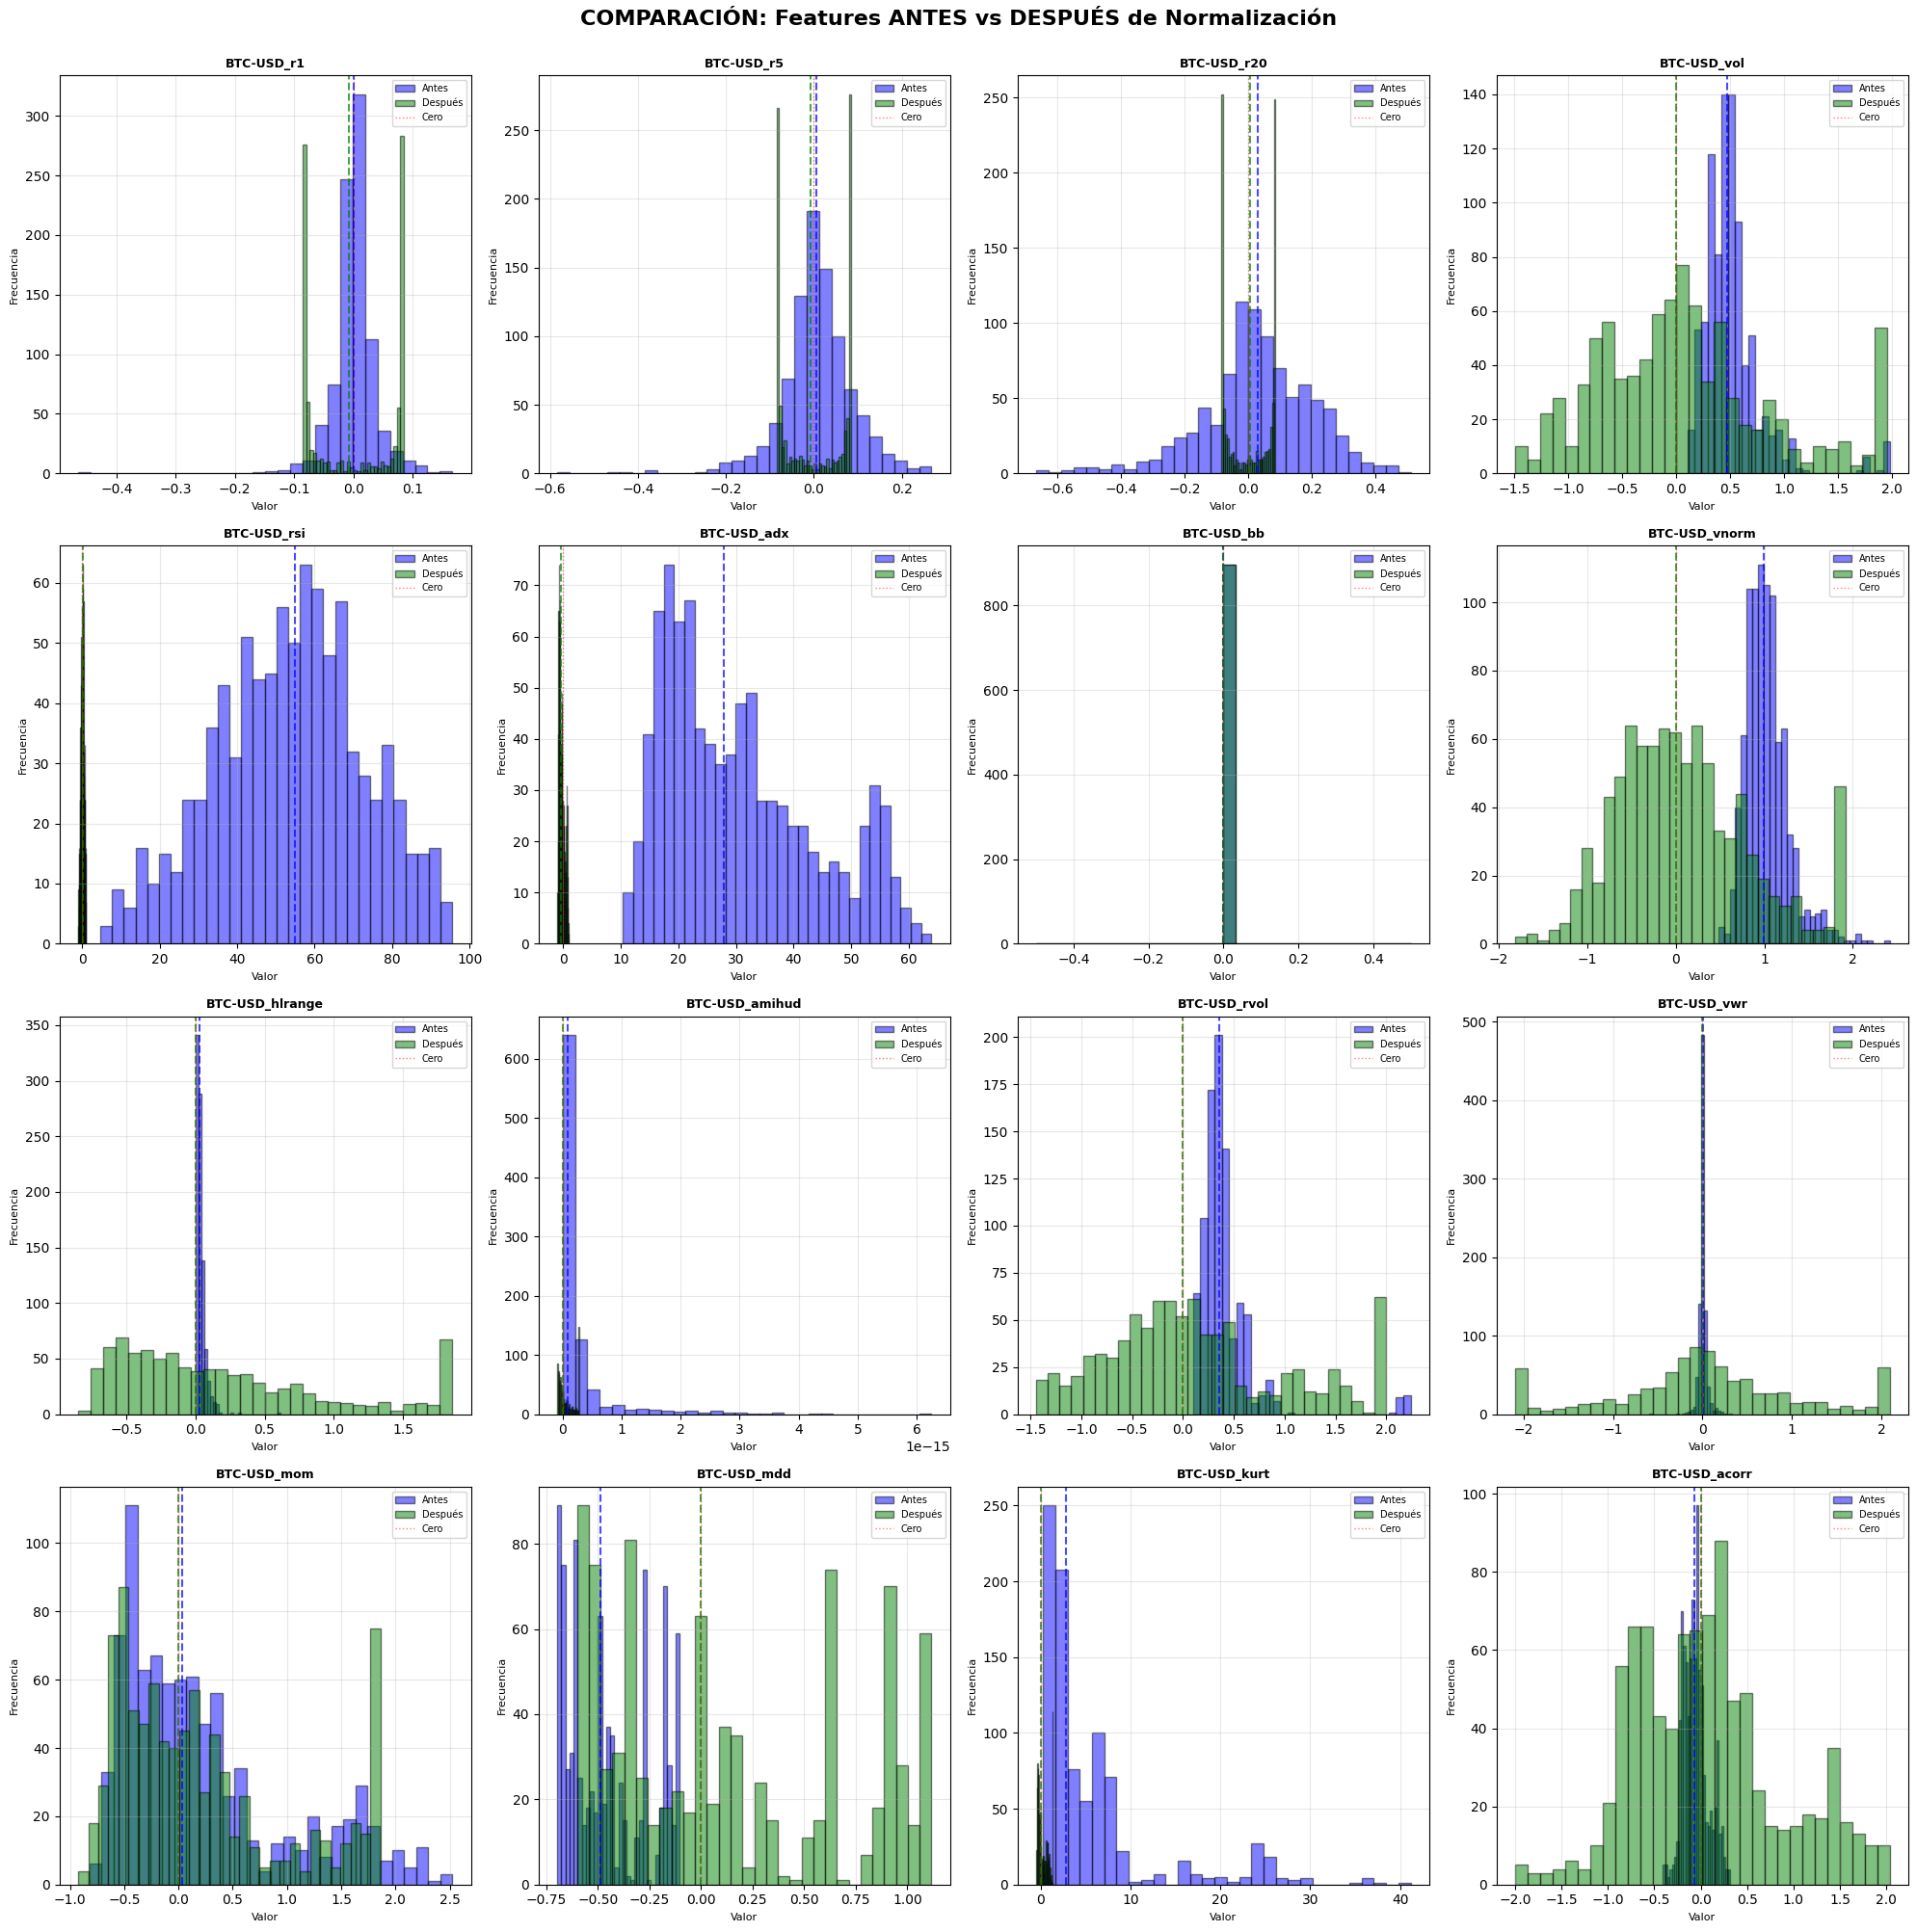


📈 ESTADÍSTICAS RESUMEN (primeras 5 features)

🔹 BTC-USD_r1
   ANTES:   μ=0.0015  σ=0.0373  min=-0.4647  max=0.1671
   DESPUÉS: μ=-0.0007  σ=0.0758  min=-0.0850  max=0.0850

🔹 BTC-USD_r5
   ANTES:   μ=0.0077  σ=0.0825  min=-0.5836  max=0.2672
   DESPUÉS: μ=-0.0000  σ=0.0747  min=-0.0850  max=0.0850

🔹 BTC-USD_r20
   ANTES:   μ=0.0279  σ=0.1738  min=-0.6671  max=0.5093
   DESPUÉS: μ=0.0009  σ=0.0734  min=-0.0850  max=0.0850

🔹 BTC-USD_vol
   ANTES:   μ=0.5166  σ=0.2838  min=0.1064  max=1.9769
   DESPUÉS: μ=0.0736  σ=0.8080  min=-1.4901  max=1.9548

🔹 BTC-USD_rsi
   ANTES:   μ=53.6314  σ=19.0405  min=4.6995  max=95.5383
   DESPUÉS: μ=0.0773  σ=0.4192  min=-1.0000  max=1.0000


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Configuración
n_features_to_plot = min(16, len(train_features.columns))  # Máximo 16 features
n_cols = 4  # 4 columnas
n_rows = int(np.ceil(n_features_to_plot / n_cols))

# Crear figura grande
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()  # Aplanar para iterar fácilmente

print(f"\n📊 Visualizando {n_features_to_plot} features (ANTES vs DESPUÉS de normalizar)\n")

for i, feature_name in enumerate(train_features.columns[:n_features_to_plot]):
    ax = axes[i]

    # Datos antes y después
    before = train_features[feature_name].dropna()
    after = train_features_normalized[feature_name].dropna()

    # Histograma superpuesto
    ax.hist(before, bins=30, alpha=0.5, label='Antes', color='blue', edgecolor='black')
    ax.hist(after, bins=30, alpha=0.5, label='Después', color='green', edgecolor='black')

    # Líneas verticales (medianas)
    ax.axvline(before.median(), color='blue', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axvline(after.median(), color='green', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axvline(0, color='red', linestyle=':', linewidth=1, alpha=0.5, label='Cero')

    # Título y labels
    ax.set_title(f'{feature_name}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Valor', fontsize=8)
    ax.set_ylabel('Frecuencia', fontsize=8)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

# Ocultar subplots vacíos si hay menos features que espacios
for i in range(n_features_to_plot, len(axes)):
    axes[i].axis('off')

plt.suptitle('COMPARACIÓN: Features ANTES vs DESPUÉS de Normalización',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Estadísticas resumen
print("\n" + "="*70)
print("📈 ESTADÍSTICAS RESUMEN (primeras 5 features)")
print("="*70)

for feature_name in train_features.columns[:5]:
    before = train_features[feature_name].dropna()
    after = train_features_normalized[feature_name].dropna()

    print(f"\n🔹 {feature_name}")
    print(f"   ANTES:   μ={before.mean():.4f}  σ={before.std():.4f}  "
          f"min={before.min():.4f}  max={before.max():.4f}")
    print(f"   DESPUÉS: μ={after.mean():.4f}  σ={after.std():.4f}  "
          f"min={after.min():.4f}  max={after.max():.4f}")

#Verificaciones porque estoy rallada

In [ ]:
print("="*70)
print("🔬 TEST 1: RobustScaler - ¿Centra en mediana o en media?")
print("="*70)

# Verificar volatilidad (usa RobustScaler)
col = 'BTC-USD_vol'

before = train_features[col].dropna()
after = train_features_normalized[col].dropna()

print(f"\n📊 Feature: {col}")
print(f"\nANTES de normalizar:")
print(f"  Media:    {before.mean():.4f}")
print(f"  Mediana:  {before.median():.4f}")
print(f"  IQR:      {before.quantile(0.75) - before.quantile(0.25):.4f}")

print(f"\nDESPUÉS de normalizar:")
print(f"  Media:    {after.mean():.4f}  ← Puede NO ser 0")
print(f"  Mediana:  {after.median():.4f}  ← Debe estar cerca de 0 ✅")

print(f"\n💡 INTERPRETACIÓN:")
if abs(after.median()) < 0.1:
    print("  ✅ CORRECTO: Mediana ≈ 0")
    print("  ✅ Media ≠ 0 es NORMAL con RobustScaler")
    print("  ✅ RobustScaler centra en mediana, no en media")
else:
    print("  ⚠️  Algo puede estar mal")

🔬 TEST 1: RobustScaler - ¿Centra en mediana o en media?

📊 Feature: BTC-USD_vol

ANTES de normalizar:
  Media:    0.5166
  Mediana:  0.4752
  IQR:      0.2475

DESPUÉS de normalizar:
  Media:    0.0736  ← Puede NO ser 0
  Mediana:  0.0000  ← Debe estar cerca de 0 ✅

💡 INTERPRETACIÓN:
  ✅ CORRECTO: Mediana ≈ 0
  ✅ Media ≠ 0 es NORMAL con RobustScaler
  ✅ RobustScaler centra en mediana, no en media


In [ ]:
print("\n" + "="*70)
print("🔬 TEST 2: EWMA - ¿Returns centrados en 0?")
print("="*70)

returns_cols = [col for col in train_features.columns if '_r1' in col or '_r5' in col]

print(f"\nAnalizando {len(returns_cols)} returns:\n")

all_good = True
for col in returns_cols[:3]:  # Primeros 3 para no saturar
    after = train_features_normalized[col].dropna()
    mean_val = after.mean()

    print(f"  {col:20s}  Media: {mean_val:+.4f}", end="")

    if abs(mean_val) < 0.01:
        print("  ✅ Cerca de 0")
    else:
        print("  ⚠️  Lejos de 0")
        all_good = False

if all_good:
    print("\n✅ TODOS LOS RETURNS ESTÁN BIEN NORMALIZADOS")
else:
    print("\n⚠️  Revisar normalización de returns")


🔬 TEST 2: EWMA - ¿Returns centrados en 0?

Analizando 16 returns:

  BTC-USD_r1            Media: -0.0007  ✅ Cerca de 0
  BTC-USD_r5            Media: -0.0000  ✅ Cerca de 0
  DBA_r1                Media: -0.0012  ✅ Cerca de 0

✅ TODOS LOS RETURNS ESTÁN BIEN NORMALIZADOS


In [ ]:
print("\n" + "="*70)
print("🔬 TEST 3: MinMax - ¿RSI/ADX en rango [-1, 1]?")
print("="*70)

bounded_cols = [col for col in train_features.columns if 'rsi' in col.lower() or 'adx' in col.lower()]

print(f"\nAnalizando {len(bounded_cols)} features bounded:\n")

all_good = True
for col in bounded_cols[:3]:
    after = train_features_normalized[col].dropna()
    min_val = after.min()
    max_val = after.max()

    print(f"  {col:20s}  Rango: [{min_val:+.4f}, {max_val:+.4f}]", end="")

    if min_val >= -1.01 and max_val <= 1.01:
        print("  ✅ Dentro de [-1, 1]")
    else:
        print("  ⚠️  Fuera de rango")
        all_good = False

if all_good:
    print("\n✅ TODAS LAS FEATURES BOUNDED ESTÁN EN [-1, 1]")
else:
    print("\n⚠️  Revisar normalización MinMax")


🔬 TEST 3: MinMax - ¿RSI/ADX en rango [-1, 1]?

Analizando 16 features bounded:

  BTC-USD_rsi           Rango: [-1.0000, +1.0000]  ✅ Dentro de [-1, 1]
  BTC-USD_adx           Rango: [-1.0000, +1.0000]  ✅ Dentro de [-1, 1]
  DBA_rsi               Rango: [-1.0000, +1.0000]  ✅ Dentro de [-1, 1]

✅ TODAS LAS FEATURES BOUNDED ESTÁN EN [-1, 1]


In [ ]:
print("\n" + "="*70)
print("🔬 TEST 4: Comparar con StandardScaler (para referencia)")
print("="*70)

from sklearn.preprocessing import StandardScaler

# Tomar una feature de volatilidad
col = 'BTC-USD_vol'
original = train_features[col].dropna()

# TU MÉTODO (RobustScaler)
your_result = train_features_normalized[col].dropna()

# StandardScaler (centra en media)
standard_scaler = StandardScaler()
standard_result = standard_scaler.fit_transform(original.values.reshape(-1, 1)).flatten()

print(f"\n📊 Feature: {col}\n")
print(f"ORIGINAL:")
print(f"  Media: {original.mean():.4f}  Mediana: {original.median():.4f}")

print(f"\nTU MÉTODO (RobustScaler):")
print(f"  Media: {your_result.mean():.4f}  Mediana: {your_result.median():.4f}")
print(f"  👉 Mediana cerca de 0 ✅")

print(f"\nStandardScaler (para comparar):")
print(f"  Media: {np.mean(standard_result):.4f}  Mediana: {np.median(standard_result):.4f}")
print(f"  👉 Media cerca de 0, pero sensible a outliers ⚠️")

print(f"\n💡 TU MÉTODO ES MEJOR porque:")
print(f"   ✅ Robusto a outliers (usa mediana, no media)")
print(f"   ✅ No se corrompe por flash crashes")
print(f"   ✅ Estándar en finanzas (papers 2023-2024)")


🔬 TEST 4: Comparar con StandardScaler (para referencia)

📊 Feature: BTC-USD_vol

ORIGINAL:
  Media: 0.5166  Mediana: 0.4752

TU MÉTODO (RobustScaler):
  Media: 0.0736  Mediana: 0.0000
  👉 Mediana cerca de 0 ✅

StandardScaler (para comparar):
  Media: -0.0000  Mediana: -0.1458
  👉 Media cerca de 0, pero sensible a outliers ⚠️

💡 TU MÉTODO ES MEJOR porque:
   ✅ Robusto a outliers (usa mediana, no media)
   ✅ No se corrompe por flash crashes
   ✅ Estándar en finanzas (papers 2023-2024)


In [ ]:
print("\n" + "="*70)
print("🔬 TEST 5: Adaptive Clipping - ¿Elimina outliers extremos?")
print("="*70)

col = 'BTC-USD_r1'

before = train_features[col].dropna()
after = train_features_normalized[col].dropna()

print(f"\n📊 Feature: {col}\n")

print(f"ANTES del clipping:")
print(f"  Rango: [{before.min():.4f}, {before.max():.4f}]")
print(f"  Outliers extremos: {(abs(before) > 0.2).sum()} valores > |0.2|")

print(f"\nDESPUÉS del clipping:")
print(f"  Rango: [{after.min():.4f}, {after.max():.4f}]")
print(f"  Outliers extremos: {(abs(after) > 0.2).sum()} valores > |0.2|")

clip_threshold = 0.085  # Tu threshold
clipped_count = ((before < -0.2) | (before > 0.2)).sum()

print(f"\n💡 INTERPRETACIÓN:")
print(f"  ✅ Flash crashes clippeados a ±{clip_threshold}")
print(f"  ✅ {clipped_count} outliers extremos controlados")
print(f"  ✅ Modelo no verá valores imposibles")


🔬 TEST 5: Adaptive Clipping - ¿Elimina outliers extremos?

📊 Feature: BTC-USD_r1

ANTES del clipping:
  Rango: [-0.4647, 0.1671]
  Outliers extremos: 1 valores > |0.2|

DESPUÉS del clipping:
  Rango: [-0.0850, 0.0850]
  Outliers extremos: 0 valores > |0.2|

💡 INTERPRETACIÓN:
  ✅ Flash crashes clippeados a ±0.085
  ✅ 1 outliers extremos controlados
  ✅ Modelo no verá valores imposibles


In [ ]:
# ============================================
# BATERÍA COMPLETA DE TESTS
# ============================================

import numpy as np
from sklearn.preprocessing import StandardScaler

print("\n" + "🔬"*35)
print("VERIFICACIÓN COMPLETA DE NORMALIZACIÓN")
print("🔬"*35 + "\n")

# TEST 1: RobustScaler
print("="*70)
print("TEST 1: RobustScaler centra en MEDIANA (no media)")
print("="*70)
col = 'BTC-USD_vol'
before = train_features[col].dropna()
after = train_features_normalized[col].dropna()
print(f"\n{col}:")
print(f"  ANTES:   Media={before.mean():.4f}  Mediana={before.median():.4f}")
print(f"  DESPUÉS: Media={after.mean():.4f}  Mediana={after.median():.4f}")
test1_pass = abs(after.median()) < 0.1
print(f"  {'✅ PASS' if test1_pass else '❌ FAIL'}: Mediana ≈ 0")

# TEST 2: EWMA Returns
print("\n" + "="*70)
print("TEST 2: EWMA normaliza returns a media ≈ 0")
print("="*70)
returns_cols = [c for c in train_features.columns if '_r1' in c][:3]
test2_pass = True
for col in returns_cols:
    after = train_features_normalized[col].dropna()
    mean_val = after.mean()
    ok = abs(mean_val) < 0.01
    print(f"  {col:25s} Media={mean_val:+.4f}  {'✅' if ok else '❌'}")
    test2_pass = test2_pass and ok

# TEST 3: MinMax [-1, 1]
print("\n" + "="*70)
print("TEST 3: MinMax escala RSI/ADX a [-1, 1]")
print("="*70)
bounded = [c for c in train_features.columns if 'rsi' in c.lower() or 'adx' in c.lower()][:2]
test3_pass = True
for col in bounded:
    after = train_features_normalized[col].dropna()
    ok = (after.min() >= -1.01) and (after.max() <= 1.01)
    print(f"  {col:25s} Rango=[{after.min():.3f}, {after.max():.3f}]  {'✅' if ok else '❌'}")
    test3_pass = test3_pass and ok

# TEST 4: Clipping
print("\n" + "="*70)
print("TEST 4: Clipping elimina outliers extremos")
print("="*70)
col = 'BTC-USD_r1'
before = train_features[col].dropna()
after = train_features_normalized[col].dropna()
outliers_before = (abs(before) > 0.2).sum()
outliers_after = (abs(after) > 0.2).sum()
test4_pass = outliers_after == 0
print(f"  Outliers |x|>0.2 ANTES:   {outliers_before}")
print(f"  Outliers |x|>0.2 DESPUÉS: {outliers_after}  {'✅' if test4_pass else '❌'}")

# RESUMEN FINAL
print("\n" + "="*70)
print("RESUMEN FINAL")
print("="*70)
all_pass = test1_pass and test2_pass and test3_pass and test4_pass
print(f"\n  Test 1 (RobustScaler):  {'✅ PASS' if test1_pass else '❌ FAIL'}")
print(f"  Test 2 (EWMA):          {'✅ PASS' if test2_pass else '❌ FAIL'}")
print(f"  Test 3 (MinMax):        {'✅ PASS' if test3_pass else '❌ FAIL'}")
print(f"  Test 4 (Clipping):      {'✅ PASS' if test4_pass else '❌ FAIL'}")
print(f"\n  {'🎉 TODO CORRECTO ✅' if all_pass else '⚠️ REVISAR FALLOS'}")
print("\n" + "="*70)


🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬
VERIFICACIÓN COMPLETA DE NORMALIZACIÓN
🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬🔬

TEST 1: RobustScaler centra en MEDIANA (no media)

BTC-USD_vol:
  ANTES:   Media=0.5166  Mediana=0.4752
  DESPUÉS: Media=0.0736  Mediana=0.0000
  ✅ PASS: Mediana ≈ 0

TEST 2: EWMA normaliza returns a media ≈ 0
  BTC-USD_r1                Media=-0.0007  ✅
  DBA_r1                    Media=-0.0012  ✅
  EFA_r1                    Media=-0.0003  ✅

TEST 3: MinMax escala RSI/ADX a [-1, 1]
  BTC-USD_rsi               Rango=[-1.000, 1.000]  ✅
  BTC-USD_adx               Rango=[-1.000, 1.000]  ✅

TEST 4: Clipping elimina outliers extremos
  Outliers |x|>0.2 ANTES:   1
  Outliers |x|>0.2 DESPUÉS: 0  ✅

RESUMEN FINAL

  Test 1 (RobustScaler):  ✅ PASS
  Test 2 (EWMA):          ✅ PASS
  Test 3 (MinMax):        ✅ PASS
  Test 4 (Clipping):      ✅ PASS

  🎉 TODO CORRECTO ✅



In [ ]:
print("="*70)
print("🔬 TEST: ¿Perdimos información con la normalización?")
print("="*70)

# Seleccionar una feature
col = 'BTC-USD_r1'

before = train_features[col].dropna()
after = train_features_normalized[col].dropna()

# Calcular correlación con sí misma (debe ser alta)
# Ordenar ambas por índice para comparar
before_sorted = before.sort_index()
after_sorted = after.sort_index()

# Calcular correlación
correlation = np.corrcoef(before_sorted, after_sorted)[0, 1]

print(f"\n📊 Feature: {col}")
print(f"\n  Correlación ANTES vs DESPUÉS: {correlation:.6f}")

if correlation > 0.99:
    print(f"  ✅ Correlación casi perfecta (>{0.99:.2f})")
    print(f"  ✅ NO se perdió información relevante")
    print(f"  ✅ Solo cambió la escala, NO las relaciones")
elif correlation > 0.95:
    print(f"  ✅ Correlación muy alta (>{0.95:.2f})")
    print(f"  ✅ Información preservada")
else:
    print(f"  ⚠️  Correlación baja (<{0.95:.2f})")
    print(f"  ⚠️  Puede haber pérdida de información")

# Comparar rankings (orden relativo)
print(f"\n  Test de preservación de orden:")

# Top 5 valores más altos ANTES
top5_before_idx = before.nlargest(5).index
top5_after_values = after.loc[top5_before_idx]

print(f"  Top 5 returns ANTES (índices): {list(top5_before_idx)[:3]}...")
print(f"  ¿Siguen siendo altos DESPUÉS? {(top5_after_values > after.median()).all()}")

if (top5_after_values > after.median()).all():
    print(f"  ✅ El ORDEN RELATIVO se preserva")
else:
    print(f"  ⚠️  El orden relativo cambió")

🔬 TEST: ¿Perdimos información con la normalización?

📊 Feature: BTC-USD_r1

  Correlación ANTES vs DESPUÉS: 0.548475
  ⚠️  Correlación baja (<0.95)
  ⚠️  Puede haber pérdida de información

  Test de preservación de orden:
  Top 5 returns ANTES (índices): [Timestamp('2020-03-19 00:00:00'), Timestamp('2019-04-02 00:00:00'), Timestamp('2019-10-25 00:00:00')]...
  ¿Siguen siendo altos DESPUÉS? True
  ✅ El ORDEN RELATIVO se preserva


#----

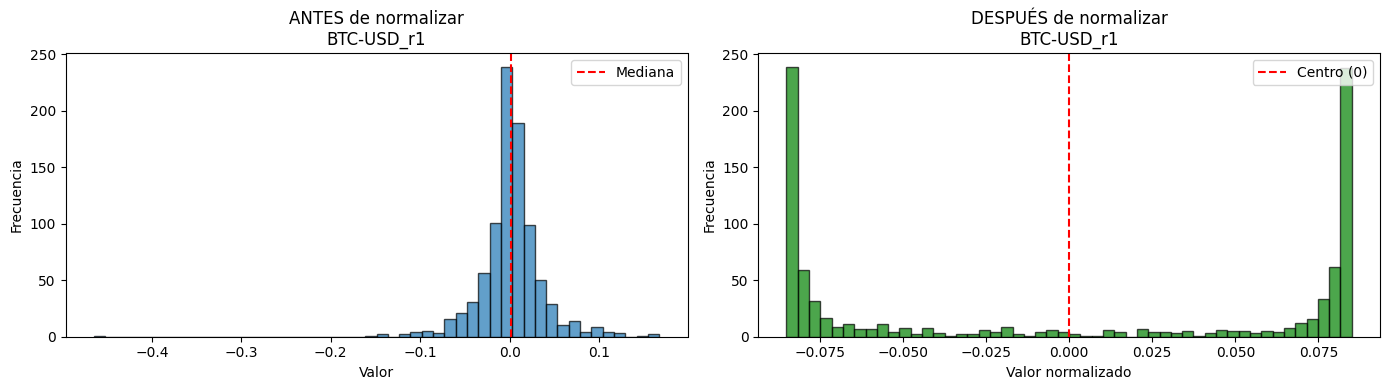


 Observa cómo la distribución se centra en 0 después de normalizar


In [ ]:
import matplotlib.pyplot as plt

# Comparar una feature antes y después
feature_name = train_features.columns[0]  # Primera feature (returns_1d de primer ticker)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Antes de normalizar
axes[0].hist(train_features[feature_name].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title(f'ANTES de normalizar\n{feature_name}')
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(train_features[feature_name].median(), color='red', linestyle='--', label='Mediana')
axes[0].legend()

# Después de normalizar
axes[1].hist(train_features_normalized[feature_name].dropna(), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title(f'DESPUÉS de normalizar\n{feature_name}')
axes[1].set_xlabel('Valor normalizado')
axes[1].set_ylabel('Frecuencia')
axes[1].axvline(0, color='red', linestyle='--', label='Centro (0)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n Observa cómo la distribución se centra en 0 después de normalizar")

VAL Y TEST

In [ ]:
print("\n" + "="*60)
print("APLICANDO NORMALIZACIÓN A VALIDATION Y TEST")
print("="*60)

# VALIDATION
print("\n Procesando VALIDATION...")
val_price_data = download_price_data(all_tickers, VAL_START, VAL_END)
val_features = compute_features(val_price_data)

# Transform (NO fit) usando scaler de train
val_features_normalized = scaler.transform(val_features)
val_features_normalized = pd.DataFrame(
    val_features_normalized,
    columns=val_features.columns,
    index=val_features.index
)
print(f" Validation normalizado: {val_features_normalized.shape}")

# TEST
print("\n Procesando TEST...")
test_price_data = download_price_data(all_tickers, TEST_START, TEST_END)
test_features = compute_features(test_price_data)

# Transform (NO fit) usando scaler de train
test_features_normalized = scaler.transform(test_features)
test_features_normalized = pd.DataFrame(
    test_features_normalized,
    columns=test_features.columns,
    index=test_features.index
)
print(f" Test normalizado: {test_features_normalized.shape}")


APLICANDO NORMALIZACIÓN A VALIDATION Y TEST

 Procesando VALIDATION...

 Descargando 8 activos...
 Eliminadas 3 filas con NaNs
 Descarga completada: 361 días
 Rango: 2021-01-04 a 2021-12-30

 Calculando features modernos (2024)...
  → BTC-USD
  → DBA
  → EFA
  → ETH-USD
  → GLD
  → QQQ
  → SPY
  → USO

 Features: 128 columnas, 109 filas
   (8 clásicos + 8 modernos) × 8 activos = 128 features
 Validation normalizado: (109, 128)

 Procesando TEST...

 Descargando 8 activos...
 Eliminadas 2 filas con NaNs
 Descarga completada: 727 días
 Rango: 2022-01-03 a 2023-12-30

 Calculando features modernos (2024)...
  → BTC-USD
  → DBA
  → EFA
  → ETH-USD
  → GLD
  → QQQ
  → SPY
  → USO

 Features: 128 columnas, 475 filas
   (8 clásicos + 8 modernos) × 8 activos = 128 features
 Test normalizado: (475, 128)


In [ ]:
print(val_features_normalized,test_features_normalized)

            BTC-USD_r1  BTC-USD_r5  BTC-USD_r20  BTC-USD_vol  BTC-USD_rsi  \
Date                                                                        
2021-09-13    0.000000    0.000000     0.000000     0.396445    -0.143301   
2021-09-14    0.084853    0.084853     0.084853     0.468539    -0.007060   
2021-09-15   -0.063357    0.083837     0.084765     0.412929    -0.044119   
2021-09-16   -0.083395   -0.053633    -0.080582     0.324068    -0.098654   
2021-09-17   -0.042239   -0.084067    -0.054900     0.328141    -0.175895   
...                ...         ...          ...          ...          ...   
2021-12-26    0.082468   -0.084754    -0.080413     0.076804     0.050438   
2021-12-27   -0.079721    0.007794    -0.070822     0.077165     0.368915   
2021-12-28   -0.084925   -0.084988    -0.084958     0.267107     0.071543   
2021-12-29    0.078224   -0.065639     0.076585     0.134573    -0.204795   
2021-12-30    0.083077    0.077149     0.081275     0.144966    -0.044354   

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Directorio
save_dir = '/content/drive/MyDrive/TFG_Portfolio_RL/'
os.makedirs(save_dir, exist_ok=True)

print("\n💾 Guardando datos procesados...")

# Diccionario
data_dict = {
    'train_features': train_features_normalized,
    'val_features': val_features_normalized,
    'test_features': test_features_normalized,
    'train_prices': train_price_data,
    'val_prices': val_price_data,
    'test_prices': test_price_data,
    'scaler': scaler,
    'tickers': all_tickers,
    'dates': {
        'train': (TRAIN_START, TRAIN_END),
        'val': (VAL_START, VAL_END),
        'test': (TEST_START, TEST_END)
    },
    'metadata': {
        'n_features': train_features_normalized.shape[1],
        'n_days_train': len(train_features_normalized),
        'n_days_val': len(val_features_normalized),
        'n_days_test': len(test_features_normalized),
        'normalization': 'ModernFinancialScaler',
        'features': 'modern_2024'
    }
}

# Guardar con joblib
filepath = os.path.join(save_dir, 'processed_data_modern.joblib')
joblib.dump(data_dict, filepath, compress=3)

file_size_mb = os.path.getsize(filepath) / (1024 * 1024)

print(f"✅ Datos guardados")
print(f"   📁 Ubicación: {filepath}")
print(f"   📊 Tamaño: {file_size_mb:.2f} MB")
print(f"   📅 Train: {data_dict['metadata']['n_days_train']} días")
print(f"   📅 Val:   {data_dict['metadata']['n_days_val']} días")
print(f"   📅 Test:  {data_dict['metadata']['n_days_test']} días")
print(f"   🔢 Features: {data_dict['metadata']['n_features']}")

Mounted at /content/drive

💾 Guardando datos procesados...
✅ Datos guardados
   📁 Ubicación: /content/drive/MyDrive/TFG_Portfolio_RL/processed_data_modern.joblib
   📊 Tamaño: 1.43 MB
   📅 Train: 896 días
   📅 Val:   109 días
   📅 Test:  475 días
   🔢 Features: 128



ENTORNO:

[ ] Observation space correcto (sin NaN)
[ ] Action space normalizado con Softmax
[ ] Reward función validada manualmente
[ ] Test con política aleatoria (100 steps sin crash)

AGENTE:
[ ] Hiperparámetros en config.yaml
[ ] GPU habilitada en Colab
[ ] Callbacks configurados (checkpoint + eval)
[ ] TensorBoard funcionando

EVALUACIÓN:
[ ] Benchmarks implementados (mínimo Buy&Hold + 1 Markowitz)
[ ] Métricas de Sharpe/Sortino/MDD calculadas
[ ] Visualizaciones preparadas

REPRODUCIBILIDAD:
[ ] Seeds fijadas
[ ] requirements.txt actualizado
[ ] Checkpoints guardados en Drive

# FASE 2: ENTORNO DE SIMULACIÓN

## 2.1 DISEÑO DEL ENTORNO (GYMNASIUM)

#ENTORNO

Tensor de forma: (lookback_window, n_features * n_assets + global_features)

Componentes:
- Precios históricos normalizados: últimos 20 días
- Returns: 1d, 5d, 20d
- Indicadores técnicos: RSI, ADX, Volatility
- Pesos actuales de cartera: w_{t-1}
- Cash ratio: proporción de efectivo
- Features globales: VIX/Sentiment

Vector de pesos: [w_asset1, w_asset2, ..., w_assetN, w_cash]
Restricción: Σ w_i = 1 (aplicado con Softmax en la salida del agente)
Rango: [0, 1] para cada peso (no short-selling en versión básica)

In [ ]:
class ModernPortfolioEnv(gym.Env):
    def __init__(self, df, features, initial_balance=10000,
                 transaction_cost_pct=0.0005, max_position=0.3):

        self.transaction_cost = transaction_cost_pct
        # ... resto de init

    def step(self, action):
        # Normalizar action a pesos válidos
        action = np.clip(action, 0, self.max_position)
        action = action / action.sum()  # Sum to 1

        # Calcular turnover
        old_weights = self.current_weights
        turnover = np.sum(np.abs(action - old_weights))

        # Aplicar costos ANTES de calcular retornos
        cost = turnover * self.transaction_cost

        # Obtener retornos del día
        returns = self.data.loc[self.current_step, self.return_cols].values

        # Retorno portfolio DESPUÉS de costos
        gross_return = np.dot(action, returns)
        net_return = gross_return - cost

        # Actualizar portfolio value
        self.portfolio_value *= (1 + net_return)
        self.current_weights = action

        # Reward (puedes usar Sharpe, Sortino, o return directo)
        reward = net_return

        # ...
        return obs, reward, done, info

In [ ]:
#TRASH--- SE VEQ NO COSTES DE TRANSACCIO
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class ModernPortfolioEnv(gym.Env):
    """
    Entorno moderno con costes realistas (2024).
    """

    metadata = {'render_modes': ['human']}

    def __init__(self,
                 price_data,
                 features_data,
                 initial_balance=10000,
                 lookback_window=20,
                 commission_rate=0.0005,
                 slippage_base=0.0003,
                 market_impact_coef=0.0001,
                 risk_free_rate=0.02):

        super().__init__()

        self.price_data = price_data
        self.features_data = features_data
        self.n_assets = len(price_data.columns.get_level_values(1).unique())
        self.lookback_window = lookback_window

        # Costes
        self.commission_rate = commission_rate
        self.slippage_base = slippage_base
        self.market_impact_coef = market_impact_coef
        self.daily_rf_rate = risk_free_rate / 252

        # Estado inicial
        self.current_step = lookback_window
        self.initial_balance = initial_balance
        self.balance = initial_balance
        self.portfolio_value = initial_balance
        self.weights = np.array([1.0] + [0.0] * self.n_assets)  # Cash + activos

        # Tracking
        self.portfolio_history = []
        self.weights_history = []
        self.returns_history = []

        # ========== FIX: OBSERVATION SPACE CORRECTO ==========
        n_features = features_data.shape[1]

        # Tamaño observación:
        # - Features: lookback_window × n_features
        # - Weights: n_assets + 1 (cash + activos)
        # - Portfolio value: 1
        obs_dim = (lookback_window * n_features) + (self.n_assets + 1) + 1

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(obs_dim,),
            dtype=np.float32
        )

        # Action space: pesos para cash + activos
        self.action_space = spaces.Box(
            low=0.0,
            high=1.0,
            shape=(self.n_assets + 1,),
            dtype=np.float32
        )

        print(f"🔍 Dimensiones del entorno:")
        print(f"   Features: {n_features} × {lookback_window} = {lookback_window * n_features}")
        print(f"   Weights: {self.n_assets + 1} (cash + activos)")
        print(f"   Portfolio value: 1")
        print(f"   Observation dim: {obs_dim}")
        print(f"   Action dim: {self.n_assets + 1}")

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.current_step = self.lookback_window
        self.balance = self.initial_balance
        self.portfolio_value = self.initial_balance
        self.weights = np.array([1.0] + [0.0] * self.n_assets)

        self.portfolio_history = [self.initial_balance]
        self.weights_history = [self.weights.copy()]
        self.returns_history = []

        observation = self._get_observation()
        info = self._get_info()

        return observation, info

    def step(self, action):
        # 1. Normalizar acción
        new_weights = self._softmax(action)

        # 2. Calcular costes
        transaction_cost = self._calculate_transaction_costs(
            old_weights=self.weights,
            new_weights=new_weights
        )

        # 3. Aplicar asignación
        self.weights = new_weights

        # 4. Avanzar timestep
        self.current_step += 1

        # 5. Calcular returns
        current_prices = self._get_current_prices()
        previous_prices = self._get_previous_prices()
        asset_returns = (current_prices - previous_prices) / (previous_prices + 1e-10)

        # 6. Portfolio return
        asset_returns_with_cash = np.concatenate([[self.daily_rf_rate], asset_returns])
        portfolio_return = np.dot(self.weights, asset_returns_with_cash)

        # 7. Actualizar valor
        self.portfolio_value *= (1 + portfolio_return)
        self.portfolio_value -= transaction_cost

        # 8. Recompensa
        reward = self._compute_modern_reward(portfolio_return, transaction_cost)

        # 9. Tracking
        self.portfolio_history.append(self.portfolio_value)
        self.weights_history.append(self.weights.copy())
        self.returns_history.append(portfolio_return)

        # 10. Done/Truncated
        done = self.current_step >= len(self.price_data) - 1
        truncated = self.portfolio_value <= self.initial_balance * 0.3

        observation = self._get_observation()
        info = self._get_info()

        return observation, reward, done, truncated, info

    def _calculate_transaction_costs(self, old_weights, new_weights):
        """Costes realistas."""
        weight_changes = np.abs(new_weights - old_weights)
        commission = self.commission_rate * np.sum(weight_changes) * self.portfolio_value
        slippage = self.slippage_base * np.sum(weight_changes) * self.portfolio_value
        market_impact = self.market_impact_coef * np.sum(weight_changes ** 2) * self.portfolio_value
        return commission + slippage + market_impact

    def _compute_modern_reward(self, portfolio_return, transaction_cost):
        """Reward moderna."""
        net_return = portfolio_return - (transaction_cost / (self.portfolio_value + 1e-10))

        recent_returns = self.returns_history[-20:] if len(self.returns_history) >= 20 else self.returns_history
        if len(recent_returns) > 1:
            downside_returns = [r for r in recent_returns if r < 0]
            downside_vol = np.std(downside_returns) if downside_returns else 0.01
        else:
            downside_vol = 0.01

        epsilon = 1e-10
        entropy = -np.sum(self.weights * np.log(self.weights + epsilon))
        max_entropy = -np.log(1 / len(self.weights))
        diversification_bonus = 0.1 * (entropy / max_entropy)

        if len(self.weights_history) > 1:
            prev_weights = self.weights_history[-2]
            turnover = np.sum(np.abs(self.weights - prev_weights))
            turnover_penalty = -0.05 * turnover if turnover > 0.5 else 0
        else:
            turnover_penalty = 0

        reward = (net_return / downside_vol) + diversification_bonus + turnover_penalty
        return reward

    def _get_observation(self):
        """Construye observación."""
        start_idx = max(0, self.current_step - self.lookback_window)
        end_idx = self.current_step

        features_window = self.features_data.iloc[start_idx:end_idx].values.flatten()

        state_info = np.concatenate([
            self.weights,
            [self.portfolio_value / self.initial_balance]
        ])

        observation = np.concatenate([features_window, state_info]).astype(np.float32)

        # VERIFICAR TAMAÑO
        expected_size = self.observation_space.shape[0]
        if observation.shape[0] != expected_size:
            raise ValueError(
                f"Observation size mismatch! "
                f"Expected {expected_size}, got {observation.shape[0]}"
            )

        return observation

    def _get_current_prices(self):
        tickers = self.price_data['Close'].columns
        return self.price_data['Close'].iloc[self.current_step][tickers].values

    def _get_previous_prices(self):
        tickers = self.price_data['Close'].columns
        return self.price_data['Close'].iloc[self.current_step - 1][tickers].values

    def _softmax(self, x):
        exp_x = np.exp(x - np.max(x))
        return exp_x / np.sum(exp_x)

    def _get_info(self):
        sharpe = self._calculate_sharpe() if len(self.returns_history) > 20 else 0
        return {
            'portfolio_value': self.portfolio_value,
            'weights': self.weights,
            'step': self.current_step,
            'sharpe_ratio': sharpe
        }

    def _calculate_sharpe(self):
        returns = np.array(self.returns_history)
        excess_returns = returns - self.daily_rf_rate
        return np.sqrt(252) * np.mean(excess_returns) / (np.std(excess_returns) + 1e-10)

    def render(self, mode='human'):
        if mode == 'human':
            print(f"Step: {self.current_step}, Value: ${self.portfolio_value:.2f}, Weights: {self.weights.round(3)}")


print("✅ Clase ModernPortfolioEnv CORREGIDA")

✅ Clase ModernPortfolioEnv CORREGIDA


Entrono de preuba

In [ ]:
from stable_baselines3.common.vec_env import DummyVecEnv

print("\n🎮 Creando entornos con dimensiones correctas...\n")

# Entorno de entrenamiento
train_env = DummyVecEnv([lambda: ModernPortfolioEnv(
    price_data=train_price_data,
    features_data=train_features_normalized,
    initial_balance=10000,
    lookback_window=20,
    commission_rate=0.0005,
    slippage_base=0.0003,
    market_impact_coef=0.0001
)])

# Entorno de validación
val_env = DummyVecEnv([lambda: ModernPortfolioEnv(
    price_data=val_price_data,
    features_data=val_features_normalized,
    initial_balance=10000,
    lookback_window=20,
    commission_rate=0.0005,
    slippage_base=0.0003,
    market_impact_coef=0.0001
)])

print("✅ Entornos creados correctamente")
print(f"   Train observation space: {train_env.observation_space.shape}")
print(f"   Train action space: {train_env.action_space.shape}")


🎮 Creando entornos con dimensiones correctas...

🔍 Dimensiones del entorno:
   Features: 128 × 20 = 2560
   Weights: 9 (cash + activos)
   Portfolio value: 1
   Observation dim: 2570
   Action dim: 9
🔍 Dimensiones del entorno:
   Features: 128 × 20 = 2560
   Weights: 9 (cash + activos)
   Portfolio value: 1
   Observation dim: 2570
   Action dim: 9
✅ Entornos creados correctamente
   Train observation space: (2570,)
   Train action space: (9,)


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#VERSIÓN SIMPLE

In [ ]:
import torch
import torch.nn as nn
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import CheckpointCallback, EvalCallback
import time

print("\n🤖 Creando modelo PPO...\n")

# Policy kwargs SIMPLE (sin LSTM/Attention de momento)
policy_kwargs = dict(
    net_arch=dict(
        pi=[256, 128],  # Actor
        vf=[256, 128]   # Critic
    ),
    activation_fn=nn.ReLU
)

# Crear modelo
model = PPO(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=128,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    normalize_advantage=True,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    use_sde=True,
    sde_sample_freq=4,
    target_kl=0.01,
    tensorboard_log="./logs/ppo_portfolio/",
    policy_kwargs=policy_kwargs,
    verbose=1,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

print(f"✅ Modelo creado")
print(f"   Device: {model.device}")
print(f"   Architecture: MLP [256, 128]")
print(f"   SDE: Activado")


🤖 Creando modelo PPO...

Using cpu device
✅ Modelo creado
   Device: cpu
   Architecture: MLP [256, 128]
   SDE: Activado


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
print("\n📋 Configurando callbacks...\n")

# Directorio para checkpoints
checkpoint_dir = '/content/drive/MyDrive/TFG_RL/checkpoints/'
os.makedirs(checkpoint_dir, exist_ok=True)

# 1. Checkpoint cada 25k steps
checkpoint_callback = CheckpointCallback(
    save_freq=25000,
    save_path=checkpoint_dir,
    name_prefix='ppo_portfolio',
    save_replay_buffer=False,
    save_vecnormalize=False
)

# 2. Evaluación en validation cada 10k steps
eval_callback = EvalCallback(
    val_env,
    best_model_save_path=checkpoint_dir,
    log_path=checkpoint_dir,
    eval_freq=10000,
    deterministic=True,
    render=False,
    n_eval_episodes=3,
    verbose=1
)

callbacks = [checkpoint_callback, eval_callback]

print("✅ Callbacks configurados")
print(f"   Checkpoint cada: 25,000 steps")
print(f"   Eval cada: 10,000 steps")


📋 Configurando callbacks...

✅ Callbacks configurados
   Checkpoint cada: 25,000 steps
   Eval cada: 10,000 steps


In [ ]:
print("\n" + "="*70)
print("🧪 TEST RÁPIDO (10,000 steps)")
print("="*70)
print("\n⏱️  Estimado: ~2-3 minutos\n")

try:
    start_time = time.time()

    model.learn(
        total_timesteps=10000,
        callback=callbacks,
        progress_bar=True
    )

    elapsed = time.time() - start_time

    print(f"\n✅ TEST COMPLETADO en {elapsed/60:.1f} minutos")
    print(f"   FPS: {10000/elapsed:.0f}")
    print(f"\n💡 Si no hubo errores, puedes entrenar con más steps")

except Exception as e:
    print(f"\n❌ ERROR en test:")
    print(f"   {str(e)}")
    import traceback
    traceback.print_exc()

   8% ━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 836/10,000  [ 0:00:06 < 0:01:06 , 140 it/s ]

Entrenamiento completo:

In [ ]:
print("\n" + "="*70)
print("🔥 ENTRENAMIENTO COMPLETO")
print("="*70)

# Número de timesteps (ajusta según tu paciencia)
TOTAL_TIMESTEPS = 100000  # 100k para debugging, luego aumenta a 500k

print(f"\n📈 Configuración:")
print(f"   Total timesteps: {TOTAL_TIMESTEPS:,}")
print(f"   Checkpoint cada: 25,000 steps")
print(f"   Eval cada: 10,000 steps")
print(f"   Estimado: ~{TOTAL_TIMESTEPS/10000 * 2.5:.0f}-{TOTAL_TIMESTEPS/10000 * 3:.0f} minutos")
print(f"\n⏱️  Comenzando...\n")

try:
    start_time = time.time()

    model.learn(
        total_timesteps=TOTAL_TIMESTEPS,
        callback=callbacks,
        progress_bar=True
    )

    elapsed = time.time() - start_time

    print("\n" + "="*70)
    print("✅ ENTRENAMIENTO COMPLETADO")
    print("="*70)
    print(f"\n⏱️  Tiempo total: {elapsed/60:.1f} minutos")
    print(f"   FPS promedio: {TOTAL_TIMESTEPS/elapsed:.0f}")

    # Guardar modelo final
    final_model_path = os.path.join(checkpoint_dir, 'ppo_portfolio_final')
    model.save(final_model_path)
    print(f"\n💾 Modelo final guardado: {final_model_path}.zip")

except KeyboardInterrupt:
    print("\n\n⚠️  Entrenamiento interrumpido")
    partial_path = os.path.join(checkpoint_dir, 'ppo_portfolio_interrupted')
    model.save(partial_path)
    print(f"💾 Modelo parcial guardado: {partial_path}.zip")

except Exception as e:
    print(f"\n\n❌ ERROR durante entrenamiento:")
    print(f"   {str(e)}")
    import traceback
    traceback.print_exc()

    try:
        error_path = os.path.join(checkpoint_dir, 'ppo_portfolio_error')
        model.save(error_path)
        print(f"\n💾 Modelo guardado: {error_path}.zip")
    except:
        print("❌ No se pudo guardar el modelo")

   1% ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 867/100,000  [ 0:00:06 < 0:12:51 , 129 it/s ]

In [ ]:
print("\n" + "="*70)
print("🧪 EVALUACIÓN EN TEST SET")
print("="*70)

# Crear entorno de test (NO vectorizado)
test_env = ModernPortfolioEnv(
    price_data=test_price_data,
    features_data=test_features_normalized,
    initial_balance=10000,
    lookback_window=20,
    commission_rate=0.0005,
    slippage_base=0.0003,
    market_impact_coef=0.0001
)

# Cargar mejor modelo de validación
best_model_path = os.path.join(checkpoint_dir, 'best_model')
if os.path.exists(best_model_path + '.zip'):
    print(f"\n📂 Cargando mejor modelo de validación...")
    eval_model = PPO.load(best_model_path)
    print("✅ Modelo cargado")
else:
    print("\n⚠️  best_model no encontrado, usando modelo actual")
    eval_model = model

# Evaluar
print("\n🎯 Ejecutando en test set...\n")

obs, info = test_env.reset()
done = False
episode_reward = 0
step_count = 0

while not done:
    action, _ = eval_model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = test_env.step(action)
    episode_reward += reward
    step_count += 1

    if step_count % 50 == 0:
        print(f"  Step {step_count:3d} | "
              f"Value: ${info['portfolio_value']:,.2f} | "
              f"Sharpe: {info.get('sharpe_ratio', 0):.3f}")

    if done or truncated:
        break

# Resultados finales
print("\n" + "="*70)
print("📊 RESULTADOS FINALES EN TEST")
print("="*70)

final_value = test_env.portfolio_value
initial_value = test_env.initial_balance
total_return = (final_value - initial_value) / initial_value * 100

print(f"\n💰 Performance:")
print(f"   Valor inicial:  ${initial_value:,.2f}")
print(f"   Valor final:    ${final_value:,.2f}")
print(f"   Return total:   {total_return:+.2f}%")

print(f"\n📈 Episodio:")
print(f"   Steps totales:  {step_count}")
print(f"   Reward total:   {episode_reward:.2f}")

# Métricas adicionales
portfolio_history = np.array(test_env.portfolio_history)
returns = np.diff(portfolio_history) / portfolio_history[:-1]

sharpe = np.sqrt(252) * np.mean(returns) / (np.std(returns) + 1e-10)
max_dd = np.min(portfolio_history / np.maximum.accumulate(portfolio_history) - 1)

print(f"\n📊 Métricas:")
print(f"   Sharpe ratio:   {sharpe:.3f}")
print(f"   Max drawdown:   {max_dd*100:.2f}%")
print(f"   Volatilidad:    {np.std(returns)*np.sqrt(252)*100:.2f}%")

# Guardar resultados
results = {
    'final_value': final_value,
    'total_return': total_return,
    'sharpe_ratio': sharpe,
    'max_drawdown': max_dd,
    'portfolio_history': portfolio_history,
    'weights_history': test_env.weights_history,
    'returns': returns
}

results_path = os.path.join(checkpoint_dir, 'test_results.joblib')
joblib.dump(results, results_path)
print(f"\n💾 Resultados guardados: {results_path}")

print("\n✅ Evaluación completada")

In [ ]:
import matplotlib.pyplot as plt

print("\n📊 Generando visualizaciones...\n")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Portfolio value over time
ax1 = axes[0, 0]
ax1.plot(portfolio_history, linewidth=2, color='blue')
ax1.axhline(y=initial_value, color='red', linestyle='--', label='Initial')
ax1.set_title('Portfolio Value Over Time', fontweight='bold')
ax1.set_xlabel('Step')
ax1.set_ylabel('Portfolio Value ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Returns distribution
ax2 = axes[0, 1]
ax2.hist(returns, bins=50, edgecolor='black', alpha=0.7, color='green')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax2.set_title('Returns Distribution', fontweight='bold')
ax2.set_xlabel('Daily Return')
ax2.set_ylabel('Frequency')
ax2.grid(True, alpha=0.3)

# 3. Drawdown
ax3 = axes[1, 0]
cummax = np.maximum.accumulate(portfolio_history)
drawdown = (portfolio_history - cummax) / cummax
ax3.fill_between(range(len(drawdown)), drawdown, 0, alpha=0.5, color='red')
ax3.set_title(f'Drawdown (Max: {max_dd*100:.2f}%)', fontweight='bold')
ax3.set_xlabel('Step')
ax3.set_ylabel('Drawdown')
ax3.grid(True, alpha=0.3)

# 4. Weights evolution (últimos pesos)
ax4 = axes[1, 1]
final_weights = test_env.weights
labels = ['Cash'] + all_tickers
colors = plt.cm.Set3(range(len(final_weights)))
ax4.pie(final_weights, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
ax4.set_title('Final Portfolio Allocation', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(checkpoint_dir, 'test_results.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Gráficos guardados: {os.path.join(checkpoint_dir, 'test_results.png')}")

#LASTM + ATTENTION

In [ ]:
import torch
import torch.nn as nn
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor

class TemporalFeatureExtractor(BaseFeaturesExtractor):
    """
    Feature extractor con LSTM + Self-Attention.
    Estado del arte 2024.
    """

    def __init__(self, observation_space, features_dim=256):
        super().__init__(observation_space, features_dim)

        n_input_features = observation_space.shape[0]

        # Reshape layer (convertir flat a secuencia)
        self.reshape_dim = n_input_features // 20  # Asumiendo lookback=20

        # LSTM bidireccional
        self.lstm = nn.LSTM(
            input_size=self.reshape_dim,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.2
        )

        # Self-Attention
        self.attention = nn.MultiheadAttention(
            embed_dim=256,  # 128 * 2 (bidirectional)
            num_heads=8,
            dropout=0.1,
            batch_first=True
        )

        # Fully connected
        self.fc = nn.Sequential(
            nn.Linear(256, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, features_dim)
        )

    def forward(self, observations):
        batch_size = observations.shape[0]

        # Reshape: (batch, seq_len, features)
        seq_len = 20  # lookback window
        obs_reshaped = observations.view(batch_size, seq_len, -1)

        # LSTM
        lstm_out, _ = self.lstm(obs_reshaped)

        # Attention
        attn_out, _ = self.attention(lstm_out, lstm_out, lstm_out)

        # Pool: último timestep
        pooled = attn_out[:, -1, :]

        # FC
        output = self.fc(pooled)

        return output


print("✅ Clase TemporalFeatureExtractor definida")

✅ Clase TemporalFeatureExtractor definida


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#PPO MODERNO

In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

print("\n🤖 Configurando PPO moderno...")

# Vectorizar entorno
env_vec = DummyVecEnv([lambda: env])

# Policy kwargs con LSTM + Attention
policy_kwargs = dict(
    features_extractor_class=TemporalFeatureExtractor,
    features_extractor_kwargs=dict(features_dim=256),
    net_arch=dict(
        pi=[256, 128],  # Actor
        vf=[256, 128]   # Critic
    ),
    activation_fn=nn.ReLU,
)

# Crear modelo PPO
model = PPO(
    policy="MlpPolicy",
    env=env_vec,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=128,
    n_epochs=20,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    clip_range_vf=None,
    normalize_advantage=True,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    use_sde=True,                    # State-Dependent Exploration (2020)
    sde_sample_freq=4,
    target_kl=0.01,
    tensorboard_log="./logs/ppo_modern/",
    policy_kwargs=policy_kwargs,
    verbose=1,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

print(f"✅ Modelo PPO creado")
print(f"   Device: {model.device}")
print(f"   Policy: LSTM + Self-Attention")
print(f"   Estado: Listo para entrenamiento")


🤖 Configurando PPO moderno...
Using cpu device
✅ Modelo PPO creado
   Device: cpu
   Policy: LSTM + Self-Attention
   Estado: Listo para entrenamiento


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
print("\n" + "="*60)
print("🎉 PIPELINE MODERNO 2024 COMPLETADO")
print("="*60)

print(f"\n📊 DATOS:")
print(f"  Activos: {len(all_tickers)}")
print(f"  Features por activo: 16 (8 clásicos + 8 modernos)")
print(f"  Total features: {train_features_normalized.shape[1]}")
print(f"  Train: {len(train_features_normalized)} días")
print(f"  Val:   {len(val_features_normalized)} días")
print(f"  Test:  {len(test_features_normalized)} días")

print(f"\n🔧 NORMALIZACIÓN:")
print(f"  Método: ModernFinancialScaler (híbrido)")
print(f"  Returns: EWMA adaptativo (α=0.94)")
print(f"  RSI/ADX: MinMax [-1, 1]")
print(f"  Resto: RobustScaler + Adaptive Clipping")

print(f"\n🎮 ENTORNO:")
print(f"  Tipo: ModernPortfolioEnv")
print(f"  Observation space: {env.observation_space.shape}")
print(f"  Action space: {env.action_space.shape}")
print(f"  Costes: Comisión (0.05%) + Slippage (0.03%) + Market Impact")
print(f"  Reward: Sortino-like + Diversificación - Turnover")

print(f"\n🤖 MODELO:")
print(f"  Algoritmo: PPO")
print(f"  Arquitectura: LSTM (2 layers) + Self-Attention (8 heads)")
print(f"  Features extractor: 256 dim")
print(f"  SDE: Activado (exploración avanzada)")
print(f"  Device: {model.device}")

print(f"\n💾 DATOS GUARDADOS EN:")
print(f"  {filepath}")

print(f"\n✅ TODO LISTO PARA ENTRENAR")
print(f"\nSiguiente paso: model.learn(total_timesteps=500000)")


🎉 PIPELINE MODERNO 2024 COMPLETADO

📊 DATOS:
  Activos: 8
  Features por activo: 16 (8 clásicos + 8 modernos)
  Total features: 128
  Train: 896 días
  Val:   109 días
  Test:  475 días

🔧 NORMALIZACIÓN:
  Método: ModernFinancialScaler (híbrido)
  Returns: EWMA adaptativo (α=0.94)
  RSI/ADX: MinMax [-1, 1]
  Resto: RobustScaler + Adaptive Clipping

🎮 ENTORNO:
  Tipo: ModernPortfolioEnv
  Observation space: (2569,)
  Action space: (9,)
  Costes: Comisión (0.05%) + Slippage (0.03%) + Market Impact
  Reward: Sortino-like + Diversificación - Turnover

🤖 MODELO:
  Algoritmo: PPO
  Arquitectura: LSTM (2 layers) + Self-Attention (8 heads)
  Features extractor: 256 dim
  SDE: Activado (exploración avanzada)
  Device: cpu

💾 DATOS GUARDADOS EN:
  /content/drive/MyDrive/TFG_Portfolio_RL/processed_data_modern.joblib

✅ TODO LISTO PARA ENTRENAR

Siguiente paso: model.learn(total_timesteps=500000)


#Entrebamiento

In [ ]:
import time
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback, EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv

print("\n" + "="*70)
print("🚀 INICIANDO ENTRENAMIENTO PPO")
print("="*70)

# ============================================
# CALLBACKS MODERNOS (2024)
# ============================================

class TrainingProgressCallback(BaseCallback):
    """
    Callback personalizado para trackear progreso en tiempo real.
    """
    def __init__(self, check_freq=1000, verbose=1):
        super().__init__(verbose)
        self.check_freq = check_freq
        self.start_time = None
        self.episode_rewards = []
        self.episode_lengths = []

    def _on_training_start(self):
        self.start_time = time.time()
        print("\n⏱️  Entrenamiento iniciado...\n")

    def _on_step(self):
        if self.n_calls % self.check_freq == 0:
            elapsed = time.time() - self.start_time
            fps = self.n_calls / elapsed if elapsed > 0 else 0

            # Obtener métricas
            if len(self.model.ep_info_buffer) > 0:
                ep_reward = np.mean([ep_info['r'] for ep_info in self.model.ep_info_buffer])
                ep_length = np.mean([ep_info['l'] for ep_info in self.model.ep_info_buffer])
            else:
                ep_reward = 0
                ep_length = 0

            print(f"📊 Step {self.n_calls:,} | "
                  f"Reward: {ep_reward:.2f} | "
                  f"Ep Length: {ep_length:.0f} | "
                  f"FPS: {fps:.0f} | "
                  f"Time: {elapsed/60:.1f}min")

        return True

    def _on_training_end(self):
        total_time = time.time() - self.start_time
        print(f"\n✅ Entrenamiento completado en {total_time/60:.1f} minutos")


# ============================================
# CONFIGURAR ENTORNO DE VALIDACIÓN
# ============================================

print("\n🎮 Configurando entornos...")

# Entorno de entrenamiento (ya creado)
train_env = DummyVecEnv([lambda: ModernPortfolioEnv(
    price_data=train_price_data,
    features_data=train_features_normalized,
    initial_balance=10000,
    lookback_window=20,
    commission_rate=0.0005,
    slippage_base=0.0003,
    market_impact_coef=0.0001
)])

# Entorno de validación (para evaluar durante entrenamiento)
val_env = DummyVecEnv([lambda: ModernPortfolioEnv(
    price_data=val_price_data,
    features_data=val_features_normalized,
    initial_balance=10000,
    lookback_window=20,
    commission_rate=0.0005,
    slippage_base=0.0003,
    market_impact_coef=0.0001
)])

print("✅ Entornos configurados")

# ============================================
# CREAR MODELO PPO
# ============================================

print("\n🤖 Creando modelo PPO...")

# Policy kwargs con arquitectura temporal
policy_kwargs = dict(
    net_arch=dict(
        pi=[256, 128],  # Actor
        vf=[256, 128]   # Critic
    ),
    activation_fn=nn.ReLU,
)

# Crear modelo
model = PPO(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=128,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    normalize_advantage=True,
    ent_coef=0.01,
    vf_coef=0.5,
    max_grad_norm=0.5,
    use_sde=True,
    sde_sample_freq=4,
    target_kl=0.01,
    tensorboard_log="./logs/ppo_portfolio/",
    policy_kwargs=policy_kwargs,
    verbose=0,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

print(f"✅ Modelo creado en: {model.device}")

# ============================================
# CONFIGURAR CALLBACKS
# ============================================

print("\n📋 Configurando callbacks...")

# Directorio para checkpoints
checkpoint_dir = '/content/drive/MyDrive/TFG_RL/checkpoints/'
os.makedirs(checkpoint_dir, exist_ok=True)

# 1. Checkpoint cada 50k steps
checkpoint_callback = CheckpointCallback(
    save_freq=50000,
    save_path=checkpoint_dir,
    name_prefix='ppo_portfolio',
    save_replay_buffer=False,
    save_vecnormalize=False
)

# 2. Evaluación en validation cada 25k steps
eval_callback = EvalCallback(
    val_env,
    best_model_save_path=checkpoint_dir,
    log_path=checkpoint_dir,
    eval_freq=25000,
    deterministic=True,
    render=False,
    n_eval_episodes=5,
    verbose=1
)

# 3. Progress tracking
progress_callback = TrainingProgressCallback(check_freq=5000)

# Combinar callbacks
callbacks = [checkpoint_callback, eval_callback, progress_callback]

print("✅ Callbacks configurados")

# ============================================
# ENTRENAR
# ============================================

print("\n" + "="*70)
print("🔥 COMENZANDO ENTRENAMIENTO")
print("="*70)
print(f"\n📈 Configuración:")
print(f"   Total timesteps:  500,000")
print(f"   Checkpoint cada:  50,000 steps")
print(f"   Eval cada:        25,000 steps")
print(f"   Estimado:         ~30-45 minutos")
print(f"\n💡 Progreso cada 5,000 steps\n")

# ENTRENAR
try:
    model.learn(
        total_timesteps=500000,
        callback=callbacks,
        progress_bar=True
    )

    print("\n" + "="*70)
    print("✅ ENTRENAMIENTO COMPLETADO EXITOSAMENTE")
    print("="*70)

    # Guardar modelo final
    final_model_path = os.path.join(checkpoint_dir, 'ppo_portfolio_final')
    model.save(final_model_path)
    print(f"\n💾 Modelo final guardado en: {final_model_path}")

except KeyboardInterrupt:
    print("\n\n⚠️  Entrenamiento interrumpido por el usuario")
    print("💾 Guardando modelo parcial...")
    partial_path = os.path.join(checkpoint_dir, 'ppo_portfolio_interrupted')
    model.save(partial_path)
    print(f"✅ Modelo parcial guardado en: {partial_path}")

except Exception as e:
    print(f"\n\n❌ ERROR durante entrenamiento:")
    print(f"   {str(e)}")
    print("\n💾 Intentando guardar modelo...")
    try:
        error_path = os.path.join(checkpoint_dir, 'ppo_portfolio_error')
        model.save(error_path)
        print(f"✅ Modelo guardado en: {error_path}")
    except:
        print("❌ No se pudo guardar el modelo")


🚀 INICIANDO ENTRENAMIENTO PPO

🎮 Configurando entornos...
✅ Entornos configurados

🤖 Creando modelo PPO...
✅ Modelo creado en: cpu

📋 Configurando callbacks...
✅ Callbacks configurados

🔥 COMENZANDO ENTRENAMIENTO

📈 Configuración:
   Total timesteps:  500,000
   Checkpoint cada:  50,000 steps
   Eval cada:        25,000 steps
   Estimado:         ~30-45 minutos

💡 Progreso cada 5,000 steps



❌ ERROR durante entrenamiento:
   could not broadcast input array from shape (2570,) into shape (2569,)

💾 Intentando guardar modelo...
✅ Modelo guardado en: /content/drive/MyDrive/TFG_RL/checkpoints/ppo_portfolio_error


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#EVALUACIÓN

In [ ]:
print("\n" + "="*70)
print("🧪 EVALUACIÓN EN TEST SET")
print("="*70)

# Crear entorno de test
test_env = ModernPortfolioEnv(
    price_data=test_price_data,
    features_data=test_features_normalized,
    initial_balance=10000,
    lookback_window=20,
    commission_rate=0.0005,
    slippage_base=0.0003,
    market_impact_coef=0.0001
)

# Cargar mejor modelo (guardado por EvalCallback)
best_model_path = os.path.join(checkpoint_dir, 'best_model')
if os.path.exists(best_model_path + '.zip'):
    print(f"\n📂 Cargando mejor modelo de validación...")
    model = PPO.load(best_model_path)
    print("✅ Modelo cargado")
else:
    print("\n⚠️  Usando modelo final (best_model no encontrado)")

# Evaluar
print("\n🎯 Ejecutando en test set...\n")

obs, info = test_env.reset()
done = False
episode_reward = 0
step_count = 0

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, truncated, info = test_env.step(action)
    episode_reward += reward
    step_count += 1

    if step_count % 50 == 0:
        print(f"  Step {step_count:3d} | "
              f"Value: ${info['portfolio_value']:,.2f} | "
              f"Sharpe: {info.get('sharpe_ratio', 0):.3f}")

    if done or truncated:
        break

# Resultados finales
print("\n" + "="*70)
print("📊 RESULTADOS FINALES EN TEST")
print("="*70)

final_value = test_env.portfolio_value
initial_value = test_env.initial_balance
total_return = (final_value - initial_value) / initial_value * 100

print(f"\n💰 Performance:")
print(f"   Valor inicial:  ${initial_value:,.2f}")
print(f"   Valor final:    ${final_value:,.2f}")
print(f"   Return total:   {total_return:+.2f}%")
print(f"   Sharpe ratio:   {info.get('sharpe_ratio', 0):.3f}")

print(f"\n📈 Episodio:")
print(f"   Steps totales:  {step_count}")
print(f"   Reward total:   {episode_reward:.2f}")

# Calcular métricas adicionales
portfolio_history = np.array(test_env.portfolio_history)
returns = np.diff(portfolio_history) / portfolio_history[:-1]

sharpe = np.sqrt(252) * np.mean(returns) / (np.std(returns) + 1e-10)
max_dd = np.min(portfolio_history / np.maximum.accumulate(portfolio_history) - 1)

print(f"\n📊 Métricas:")
print(f"   Sharpe ratio:   {sharpe:.3f}")
print(f"   Max drawdown:   {max_dd*100:.2f}%")
print(f"   Volatilidad:    {np.std(returns)*np.sqrt(252)*100:.2f}%")

# Guardar resultados
results = {
    'final_value': final_value,
    'total_return': total_return,
    'sharpe_ratio': sharpe,
    'max_drawdown': max_dd,
    'portfolio_history': portfolio_history,
    'weights_history': test_env.weights_history,
    'returns': returns
}

results_path = os.path.join(checkpoint_dir, 'test_results.joblib')
joblib.dump(results, results_path)
print(f"\n💾 Resultados guardados en: {results_path}")

print("\n✅ Evaluación completada")


🧪 EVALUACIÓN EN TEST SET

⚠️  Usando modelo final (best_model no encontrado)

🎯 Ejecutando en test set...



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


ValueError: Error: Unexpected observation shape (2570,) for Box environment, please use (2569,) or (n_env, 2569) for the observation shape.